# REAL ESTATE LISTINGS IN PORTUGAL
---

### Exploratory Data Analysis, Statistical Inference & Machine Learning

# 1. Introduction
## 1.1 Business Understanding

**Goal**

The goal of this project is to analyze real estate listings in Portugal and   
develop a machine learning model capable of predicting property prices based   
on property characteristics such as size, location, number of rooms, age, and energy efficiency.  

**Business Motivation**

Accurate price prediction models can support:  
- Real estate valuation  
- Market analysis  
- Investment decision support   
- Automated property pricing systems  

Understanding which factors influence housing prices is valuable  
for buyers, sellers, and real estate platforms.  

## 1.2 Data Understanding

**Dataset**

The dataset contains real estate listings from Portugal, including information   
about property location, size, number of rooms, building characteristics, and energy efficiency.    
The target variable of interest is:  
**Price → property listing price**  
The dataset includes both numerical and categorical features describing location    
and structural characteristics of the properties.  
<table align="left">
<tr><th>Category</th><th>Features</th></tr>
<tr><td>Location</td><td>District, City, Town</td></tr>
<tr><td>Property Type</td><td>Type</td></tr>
<tr><td>Property Size</td><td>TotalArea, LivingArea</td></tr>
<tr><td>Property Structure</td><td>TotalRooms, NumberOfBedrooms, NumberOfBathrooms, NumberOfWC</td></tr>
<tr><td>Property Characteristics</td><td>Parking, PropertyAge</td></tr>
<tr><td>Energy Efficiency</td><td>EnergyEfficiencyScore</td></tr>
<tr><td>Derived Features</td><td>rooms_per_m2</td></tr>
</table>

<br clear="all">

Target variable:
**Price — the total listing price of the property.**
Dataset size:  
- ~123,000 observations  
- Multiple property types including apartments, houses, land, and commercial properties.  

## 1.3 Data Cleaning

**Removal of Invalid Values**

Initial data exploration revealed the presence of unrealistic or invalid values    
in certain columns. Observations with missing or zero values in key variables   
such as Price and TotalArea were removed to ensure that the derived metric price    
per square meter could be calculated correctly.

**Outlier Handling**

Extreme values in **price per square mete**r were detected across several property categories.    
Since these values often represent data entry errors, placeholder prices, or unusual listings,   
the dataset was cleaned by removing observations outside the **1st and 99th percentiles within    
each property category**.

This approach helps reduce the influence of extreme outliers while preserving    
the majority of valid observations.

**Feature Engineering**

Several additional variables were created to improve the analytical and predictive capabilities of the dataset:
- **price_per_m2** – price per square meter, allowing comparison across properties of different sizes
- **PropertyAge** – calculated from the construction year to represent the age of the property
- **rooms_per_m2** – ratio between number of rooms and total area to capture property layout density

These derived features provide additional insights into property characteristics that may influence price.

**Missing Values**

The dataset contains missing values in several features such as   
**EnergyEfficiencyScore, TotalRooms, and PropertyAge**.   
Rather than removing large portions of the dataset, missing values   
were handled during the modeling stage using imputation techniques   
within machine learning pipelines.

In [123]:
# ================================
# Standard Library
# ================================
import os
from pathlib import Path
import datetime
import warnings
from IPython.display import HTML

warnings.filterwarnings("ignore")

# ================================
# Data Handling
# ================================
import numpy as np
import pandas as pd

# ================================
# Visualization
# ================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display
import importlib
import realestateplot

importlib.reload(realestateplot)

sns.set_theme(style="whitegrid")

# ================================
# Statistics
# ================================
import scipy.stats as stats
from scipy.stats import ttest_ind, mannwhitneyu, shapiro, kruskal

# ================================
# Machine Learning
# ================================
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_predict

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    VotingRegressor
)

# ================================
# Plots
# ================================
from realestateplot import (
    plot_outliers_before_after,
    plot_price_distribution_by_category,
    plot_property_age_distribution,
    plot_price_and_log_price_distribution,
    plot_property_characteristics_vs_price,
    plot_price_by_property_category,
    plot_property_age_by_energy_efficiency,
    plot_district_price_and_listing_counts,
    plot_district_category_distribution,
    plot_top_cities_by_category,
    plot_map,
    plot_correlation_heatmap,
    plot_correlation_with_price,
    plot_lisbon_porto_distributions,
    plot_new_old_distributions,
    plot_energy_group_distributions,
    plot_category_confidence_intervals,
    plot_model_rmse_comparison,
    plot_actual_vs_predicted,
    plot_feature_importance,
    plot_residuals_vs_predicted,
    plot_model_comparison_rmse,
)

# ================================
# Model Saving
# ================================
import joblib

In [2]:
df = pd.read_csv("portugal_listinigs.csv")
df.head()

,Price,District,City,Town,Type,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,780000.0,Vila Real,Valpaços,Carrazedo de Montenegro e Curros,Farm,NC,200.0,552450.0,0.0,False,...,False,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,0.0
1,223000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,81.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,81.0,NaN,NaN,2.0
2,228000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,108.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,108.0,NaN,NaN,2.0
3,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,0.0
4,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0


----------------------------------------

# 2. Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135536 entries, 0 to 135535
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  135236 non-null  float64
 1   District               135536 non-null  object 
 2   City                   135536 non-null  object 
 3   Town                   135534 non-null  object 
 4   Type                   135520 non-null  object 
 5   EnergyCertificate      135522 non-null  object 
 6   GrossArea              27638 non-null   float64
 7   TotalArea              127153 non-null  float64
 8   Parking                135342 non-null  float64
 9   HasParking             68215 non-null   object 
 10  Floor                  27929 non-null   object 
 11  ConstructionYear       88021 non-null   float64
 12  EnergyEfficiencyLevel  67289 non-null   object 
 13  PublishDate            29239 non-null   object 
 14  Garage                 67289 non-nul

In [4]:
df_clean = df.copy()

## 2.1 Missing Values

Several variables contained missing values, particularly structural property characteristics such as number of bedrooms or property age.  
- Numerical features were imputed using median values  
- Categorical features were imputed using most frequent values  
This approach preserves dataset size while minimizing bias.  

In [5]:
summary = (
    pd.DataFrame({
        "dtype": df_clean.dtypes,
        "unique_values": df_clean.nunique(dropna=False),
        "missing_ratio": df_clean.isna().mean()
    })
    .sort_values("missing_ratio", ascending=False)
)

summary

,dtype,unique_values,missing_ratio
ConservationStatus,object,7,0.857661
BuiltArea,float64,7297,0.803617
GrossArea,float64,2268,0.796084
Floor,object,20,0.793937
PublishDate,object,27833,0.784271
LotSize,float64,6779,0.707952
NumberOfBedrooms,float64,23,0.652926
NumberOfWC,float64,28,0.577559
Garage,object,3,0.503534
EnergyEfficiencyLevel,object,12,0.503534


**Columns droper with more thann 75% ratio**

In [6]:
df_clean.drop(columns=[
    "HasParking",
    "Elevator",
    "ElectricCarsCharging",
    "Garage",
    "ConservationStatus",
    "PublishDate",
    "BuiltArea",
    "GrossArea",
    "Floor",
    "LotSize"
], inplace=True)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135536 entries, 0 to 135535
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  135236 non-null  float64
 1   District               135536 non-null  object 
 2   City                   135536 non-null  object 
 3   Town                   135534 non-null  object 
 4   Type                   135520 non-null  object 
 5   EnergyCertificate      135522 non-null  object 
 6   TotalArea              127153 non-null  float64
 7   Parking                135342 non-null  float64
 8   ConstructionYear       88021 non-null   float64
 9   EnergyEfficiencyLevel  67289 non-null   object 
 10  TotalRooms             73244 non-null   float64
 11  NumberOfBedrooms       47041 non-null   float64
 12  NumberOfWC             57256 non-null   float64
 13  LivingArea             104952 non-null  float64
 14  NumberOfBathrooms      128700 non-nu

**NumberOfWC vs NumberOfBathrooms Corr**

In [7]:
df_clean[["NumberOfWC", "NumberOfBathrooms"]].corr()

,NumberOfWC,NumberOfBathrooms
NumberOfWC,1.00000,0.49674
NumberOfBathrooms,0.49674,1.00000


<table align="left">
<tr><th>Column</th><th>Missing</th><th>Unique</th></tr>
<tr><td>NumberOfWC</td><td>57.7%</td><td>28</td></tr>
<tr><td>NumberOfBathrooms</td><td>5%</td><td>47</td></tr>
</table>

<br clear="all">

**Contain Same Values**

In [8]:
contais_same_values=(df_clean["NumberOfWC"] == df_clean["NumberOfBathrooms"]).mean()

mask = df_clean["NumberOfWC"].notna() & df_clean["NumberOfBathrooms"].notna()
contais_same_values_nonull=(df_clean.loc[mask, "NumberOfWC"] 
 == df_clean.loc[mask, "NumberOfBathrooms"]).mean()

print("Contain Same Values:", contais_same_values)
print("Contain Same Values without null:", contais_same_values_nonull)

Contain Same Values: 0.1938968244599221
Contain Same Values without null: 0.4589911974290904


**NumberOfWC** and **NumberOfBathrooms** are NOT redundant variables.  
They represent different things.  

- NumberOfBathrooms = full bathrooms  
- NumberOfWC = total toilets (may include guest WC, half bath)

**Fix Price**

In [9]:
df_clean = df_clean[
    df_clean["Price"].notna() &
    df_clean["TotalArea"].notna() &
    (df_clean["TotalArea"] > 0) &
    (df_clean["Price"] > 0)
]

df_clean["price_per_m2"] = df_clean["Price"] / df_clean["TotalArea"]

In [10]:
type_mapping = {
    "Apartment": "Apartment",
    "Duplex": "Apartment",
    "Studio": "Apartment",

    "House": "House",
    "Mansion": "House",
    "Manor": "House",

    "Land": "Land/Farm",
    "Farm": "Land/Farm",
    "Estate": "Land/Farm",
    "Investment": "Land/Farm",

    "Store": "Commercial/Other",
    "Office": "Commercial/Other",
    "Building": "Commercial/Other",
    "Warehouse": "Commercial/Other",
    "Industrial": "Commercial/Other",
    "Garage": "Commercial/Other",
    "Other - Commercial": "Commercial/Other",
    "Other - Residential": "Commercial/Other",
    "Transfer of lease": "Commercial/Other",
    "Hotel": "Commercial/Other",
    "Storage": "Commercial/Other"
}

df_clean["Category"] = df_clean["Type"].map(type_mapping)
df_clean["Category"].value_counts()

Category
Apartment           47155
House               36639
Land/Farm           27457
Commercial/Other    14675
Name: count, dtype: int64

## 2.2 Outlier Handling

Extreme property prices were detected using quantile filtering (1%–99%).  
This step removed unrealistic listings and helped stabilize model training.  
Outlier removal reduced noise in the dataset and improved the reliability of    
statistical analysis and machine learning models.  

In [11]:
clean_list = []
outliers_list = []

for cat in df_clean["Category"].dropna().unique():

    temp = df_clean[df_clean["Category"] == cat]

    q_low = temp["price_per_m2"].quantile(0.01)
    q_high = temp["price_per_m2"].quantile(0.99)

    mask_outliers = (temp["price_per_m2"] < q_low) | (temp["price_per_m2"] > q_high)

    outliers_list.append(temp[mask_outliers])   
    clean_list.append(temp[~mask_outliers])     

In [12]:
df_outliers = pd.concat(outliers_list)
df_clean_after = pd.concat(clean_list)

df_clean_after.reset_index(drop=True, inplace=True)

In [13]:
df_outliers[["Category","Price","TotalArea","price_per_m2","District","Type"]].head(10)

,Category,Price,TotalArea,price_per_m2,District,Type
399,Land/Farm,35000.0,83440.0,0.419463,Faro,Land
401,Land/Farm,28000.0,55400.0,0.505415,Faro,Land
1327,Land/Farm,46000.0,76880.0,0.598335,Faro,Land
1651,Land/Farm,790000.0,60.0,13166.666667,Faro,Land
1876,Land/Farm,2500.0,4200.0,0.595238,Porto,Land
1906,Land/Farm,7300.0,14207.0,0.513831,Viseu,Land
1910,Land/Farm,12300.0,20600.0,0.597087,Viseu,Land
1914,Land/Farm,90000.0,203000.0,0.443350,Guarda,Farm
1933,Land/Farm,70000.0,239600.0,0.292154,Guarda,Farm
1950,Land/Farm,110000.0,233600.0,0.470890,Guarda,Land


In [14]:
print("Before cleaning")
print(df_clean.groupby("Category")["price_per_m2"].describe())

print("\nAfter cleaning")
print(df_clean_after.groupby("Category")["price_per_m2"].describe())

Before cleaning
                    count         mean           std       min          25%  \
Category                                                                      
Apartment         47155.0  3442.095662  11127.523587  0.003282  1993.288288   
Commercial/Other  14675.0  2150.440806  23335.353625  0.009825   557.571471   
House             36639.0  1948.449028  29891.326040  0.006757   468.750000   
Land/Farm         27457.0   556.409379  10763.370420  0.000001    10.917031   

                          50%          75%        max  
Category                                               
Apartment         2897.727273  4165.476190  1950000.0  
Commercial/Other  1053.191489  2000.000000  2200000.0  
House             1182.222222  2226.762386  5000000.0  
Land/Farm           46.296296   169.491525  1300000.0  

After cleaning
                    count         mean          std        min          25%  \
Category                                                                      

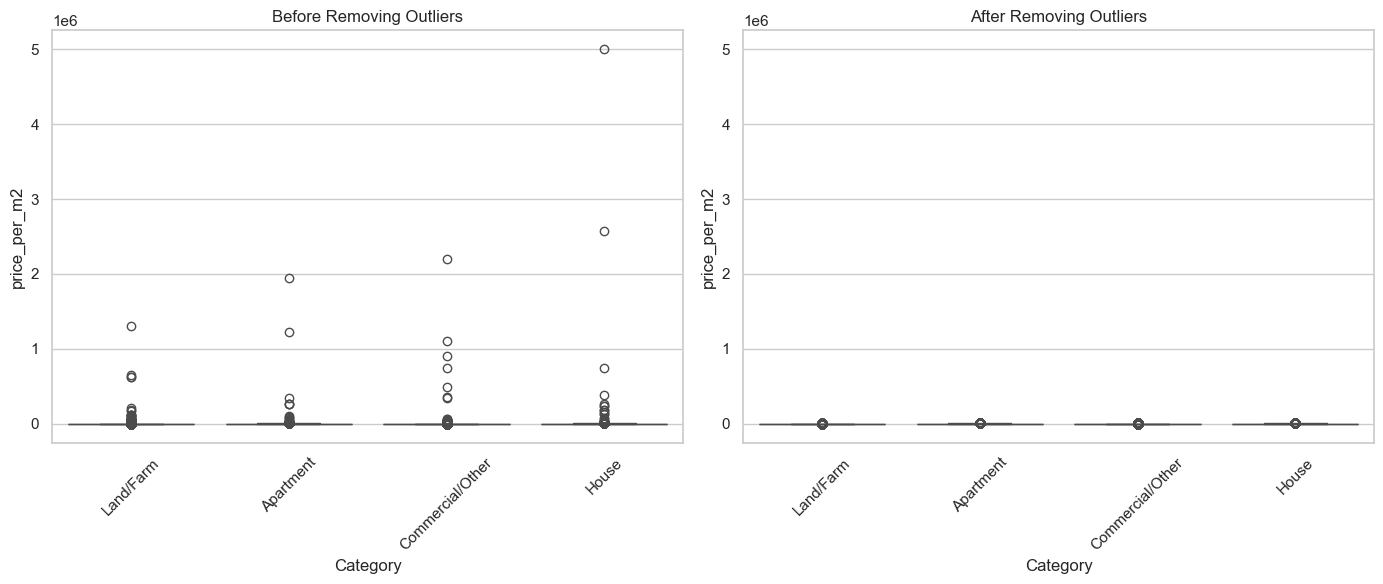

In [15]:
plot_outliers_before_after(df_clean, df_clean_after)

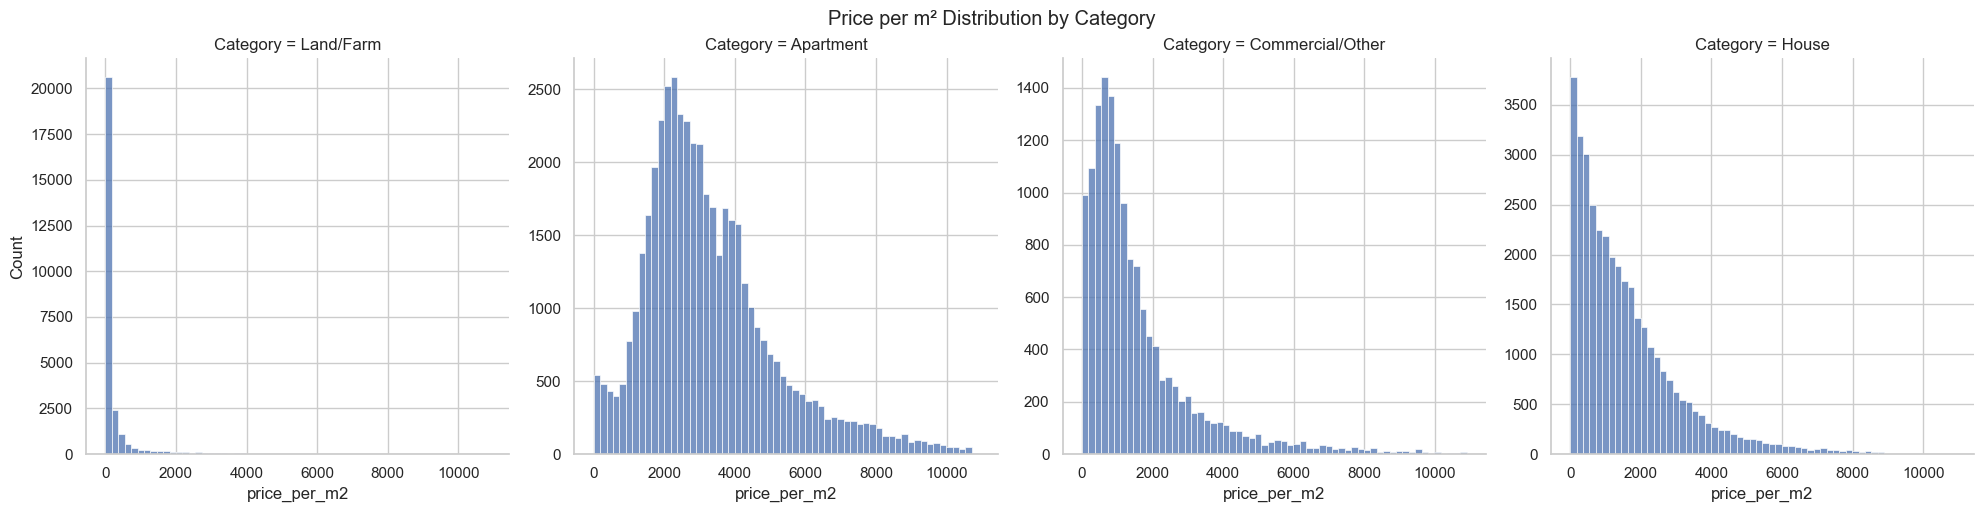

In [16]:
plot_price_distribution_by_category(df_clean_after)

Before cleaning, the price_per_m2 variable contained extreme values    
across all property categories. The minimum prices were close to zero,   
while the maximum values reached unrealistic levels (e.g., several million €/m²).    
These anomalies were likely caused by incorrect area values, placeholder prices,    
or data entry errors.  

To improve data quality, outliers were removed separately within each    
property category using the 1st and 99th percentile thresholds.    
This approach accounts for the fact that different property types    
(apartments, houses, land, and commercial properties) naturally have different price ranges.  

After cleaning, the maximum values and standard deviations decreased significantly,    
indicating a more stable distribution. At the same time, the median prices    
remained almost unchanged, suggesting that only extreme observations    
were removed while the overall market trends were preserved.  

**Cleaning negative values as NaN**

<table align="left">
<tr><th>Column</th><th>Problem</th></tr>
<tr><td>GrossArea</td><td>min = <b>-7</b></td></tr>
<tr><td>BuiltArea</td><td>min = <b>-1</b></td></tr>
<tr><td>NumberOfWC</td><td>min = <b>-15</b></td></tr>
<tr><td>NumberOfBathrooms</td><td>min = <b>-13</b></td></tr>
<tr><td>TotalRooms</td><td>max = <b>2751</b></td></tr>
<tr><td>NumberOfBedrooms</td><td>max = <b>21</b></td></tr>
<tr><td>NumberOfWC</td><td>max = <b>59</b></td></tr>
</table>

<br clear="all">

In [17]:
print(df_clean_after.shape)

(123407, 17)


In [18]:
df_clean_after = pd.concat(clean_list)
df_clean_after.reset_index(drop=True, inplace=True)

df_clean = df_clean_after
del df_clean_after

In [19]:
print(df_clean.shape)

(123407, 17)


In [20]:
cols = [
    "NumberOfWC",
    "NumberOfBathrooms",
    "LivingArea",
    "TotalRooms",
    "NumberOfBedrooms"
]

for col in cols:
    df_clean.loc[df_clean[col] < 0, col] = None

**Unrealistic room counts**

<table align="left">
<tr><th>Feature</th><th>Realistic range</th></tr>
<tr><td>Bedrooms</td><td>0–10</td></tr>
<tr><td>Bathrooms</td><td>0–10</td></tr>
<tr><td>WC</td><td>0–10</td></tr>
<tr><td>TotalRooms</td><td>1–20</td></tr>
</table>

<br clear="all">

In [21]:
df_clean.loc[df_clean["NumberOfBedrooms"] > 10, "NumberOfBedrooms"] = None
df_clean.loc[df_clean["NumberOfBathrooms"] > 10, "NumberOfBathrooms"] = None
df_clean.loc[df_clean["NumberOfWC"] > 10, "NumberOfWC"] = None
df_clean.loc[df_clean["TotalRooms"] > 20, "TotalRooms"] = None

**Clean ConstructionYear**

In [22]:
df_clean["ConstructionYear"].describe()

count    84908.000000
mean      1989.372886
std         26.616105
min       1900.000000
25%       1973.000000
50%       1994.000000
75%       2009.000000
max       2025.000000
Name: ConstructionYear, dtype: float64

In [23]:
df_clean.loc[df_clean["ConstructionYear"] < 1800, "ConstructionYear"] = np.nan
df_clean.loc[df_clean["ConstructionYear"] > datetime.datetime.now().year, "ConstructionYear"] = np.nan

current_year = datetime.datetime.now().year
df_clean["PropertyAge"] = current_year - df_clean["ConstructionYear"]

In [24]:
df_clean[["ConstructionYear","PropertyAge"]].describe()

,ConstructionYear,PropertyAge
count,84908.000000,84908.000000
mean,1989.372886,36.627114
std,26.616105,26.616105
min,1900.000000,1.000000
25%,1973.000000,17.000000
50%,1994.000000,32.000000
75%,2009.000000,53.000000
max,2025.000000,126.000000


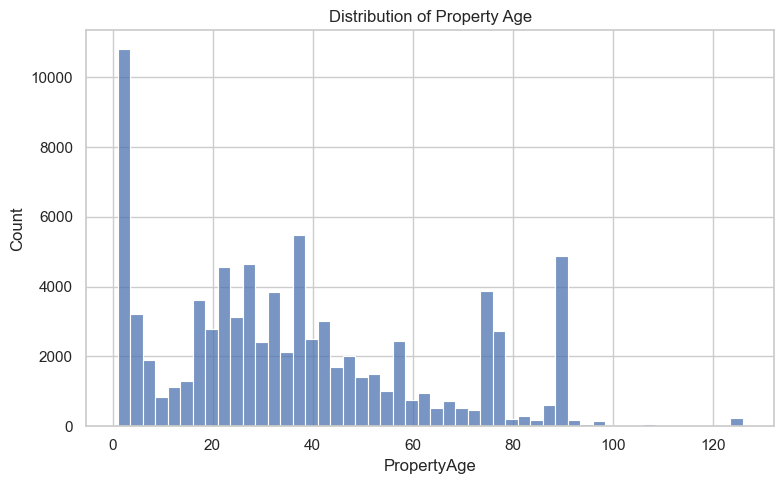

In [25]:
plot_property_age_distribution(df_clean)

In [26]:
missing_ratio = df_clean.isnull().mean().sort_values(ascending=False)
print(missing_ratio)

NumberOfBedrooms         0.631366
NumberOfWC               0.599796
EnergyEfficiencyLevel    0.534297
TotalRooms               0.429878
PropertyAge              0.311968
ConstructionYear         0.311968
LivingArea               0.177502
NumberOfBathrooms        0.040614
Parking                  0.001288
Town                     0.000016
District                 0.000000
Price                    0.000000
Type                     0.000000
EnergyCertificate        0.000000
TotalArea                0.000000
City                     0.000000
price_per_m2             0.000000
Category                 0.000000
dtype: float64


In [27]:
df_clean["rooms_per_m2"] = df_clean["TotalRooms"] / df_clean["TotalArea"]

In [28]:
df_clean["EnergyEfficiencyLevel"].unique()

array([nan, 'NC', 'F', 'E', 'D', 'B', 'C', 'A+', 'A', 'G', 'B-',
       'No Certificate'], dtype=object)

In [29]:
df_clean["EnergyEfficiencyLevel"] = df_clean["EnergyEfficiencyLevel"].replace(
    ["NC", "No Certificate"],
    np.nan
)

energy_order = ["A+", "A", "B", "B-", "C", "D", "E", "F", "G"]

df_clean["EnergyEfficiencyLevel"] = pd.Categorical(
    df_clean["EnergyEfficiencyLevel"],
    categories=energy_order,
    ordered=True
)

energy_map = {
    "A+": 9,
    "A": 8,
    "B": 7,
    "B-": 6,
    "C": 5,
    "D": 4,
    "E": 3,
    "F": 2,
    "G": 1
}

df_clean["EnergyEfficiencyScore"] = df_clean["EnergyEfficiencyLevel"].map(energy_map)

In [30]:
df_clean.drop(columns=["EnergyCertificate"], inplace=True)

In [31]:
df_clean["EnergyEfficiencyScore"].unique()

[NaN, 2, 3, 4, 7, 5, 9, 8, 1, 6]
Categories (9, int64): [9 < 8 < 7 < 6 ... 4 < 3 < 2 < 1]

## 2.3 Duplicate Check

The dataset was checked for duplicated rows to ensure data integrity.  
No significant duplicate entries were found, suggesting that the dataset primarily contains unique property listings.

In [32]:
df_clean[df_clean.duplicated(subset=["Price","TotalArea","City"])].head()

,Price,District,City,Town,Type,TotalArea,Parking,ConstructionYear,EnergyEfficiencyLevel,TotalRooms,NumberOfBedrooms,NumberOfWC,LivingArea,NumberOfBathrooms,price_per_m2,Category,PropertyAge,rooms_per_m2,EnergyEfficiencyScore
15,120000.0,Faro,Tavira,Tavira (Santa Maria e Santiago),Land,210.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,571.428571,Land/Farm,NaN,NaN,NaN
28,120000.0,Faro,Tavira,Tavira (Santa Maria e Santiago),Land,210.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,571.428571,Land/Farm,NaN,NaN,NaN
29,120000.0,Faro,Tavira,Tavira (Santa Maria e Santiago),Land,210.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,571.428571,Land/Farm,NaN,NaN,NaN
30,120000.0,Faro,Tavira,Tavira (Santa Maria e Santiago),Land,210.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,571.428571,Land/Farm,NaN,NaN,NaN
31,120000.0,Faro,Tavira,Tavira (Santa Maria e Santiago),Land,210.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,571.428571,Land/Farm,NaN,NaN,NaN


The dataset contains approximately 11,845 duplicated rows. However,     
since no unique property identifier is available, these rows cannot    
be confidently identified as true duplicates. Identical values may     
correspond to multiple units within the same building or similar     
land listings. Therefore, duplicate rows were retained to avoid removing    
potentially valid observations.

----------------------------------------------------------------

# 3. Exploratory Data Analysis (EDA)
## 3.1 Price Distribution

Property prices show strong right skewness, meaning a small number   
of high-value properties significantly increase the average price.    
Because of this skewness, non-parametric statistical tests were preferred in later analysis.

**Price per square meter distribution**

The original price distribution is strongly right-skewed, while the log-transformed    
price is much closer to a symmetric distribution. This suggests that price    
transformation may be useful for later modeling.

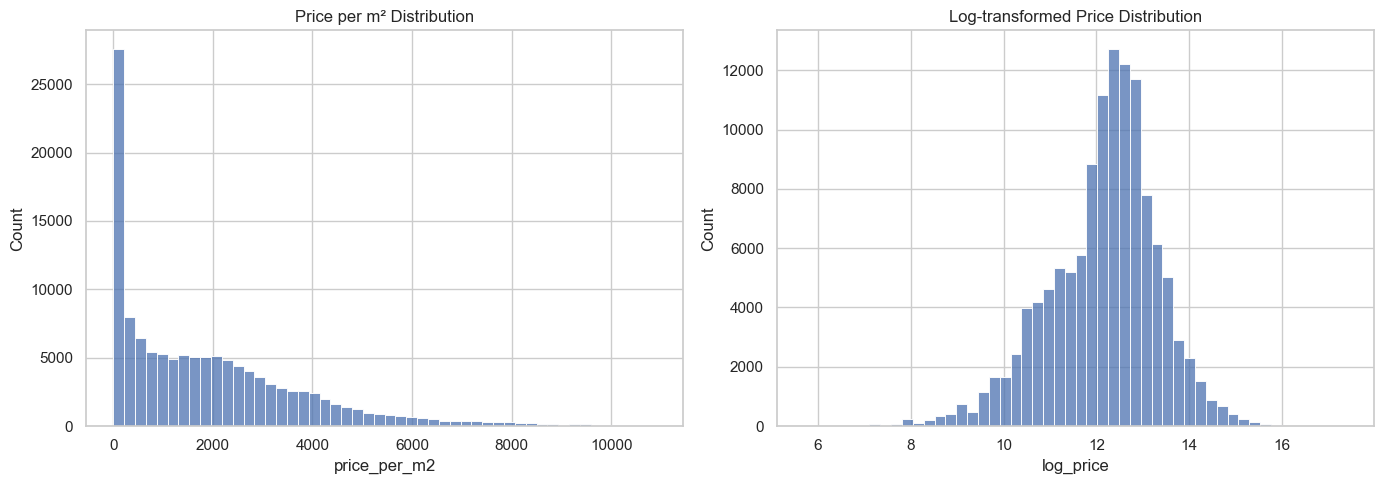

In [33]:
plot_price_and_log_price_distribution(df_clean)

**Property characteristics affecting price**

**Price per m² vs Living Area**
The scatter plot suggests a negative relationship between living area and price   
per square meter. Smaller properties tend to have higher price per m², while     
larger properties often have lower unit prices, reflecting common real estate market behavior.
 
-Small apartments often in city centers  
-large houses often in suburbs or rural areas  

**Price per m² vs Property Age**  
The regression trend indicates that newer properties tend to have higher prices     
per square meter, while older properties generally show lower price levels and greater variability.  
 
- Modern construction standards  
- better insulation  
- modern infrastructure

**Price per m² by Total Rooms**   
Properties with fewer rooms tend to have higher price per square meter.    
As the number of rooms increases, the median price per m² generally decreases,     
suggesting that larger dwellings provide lower unit price relative to size.  

**Price per m² by Energy Efficiency**  
Properties with higher energy efficiency ratings generally exhibit higher    
price per square meter. However, the difference between the highest     
efficiency categories (A+ and A) is relatively small, which may reflect     
limited availability of A+ buildings or other market factors such as location and property type.  

- Stricter standards introduced relatively recently  
- renovation of old buildings is expensive  
- A+ buildings are still limited in supply.
- 
**Price per m² by Property Category**   
Apartments exhibit the highest median price per square meter, followed by   
houses and commercial properties, while land and farm properties have   
 the lowest prices. This reflects the higher demand and location concentration   
 of residential apartments, particularly in urban areas.  

Overall, the analysis suggests that property characteristics such as size, age,      
energy efficiency, and property type significantly influence the price per square     
meter in the Portuguese real estate market.

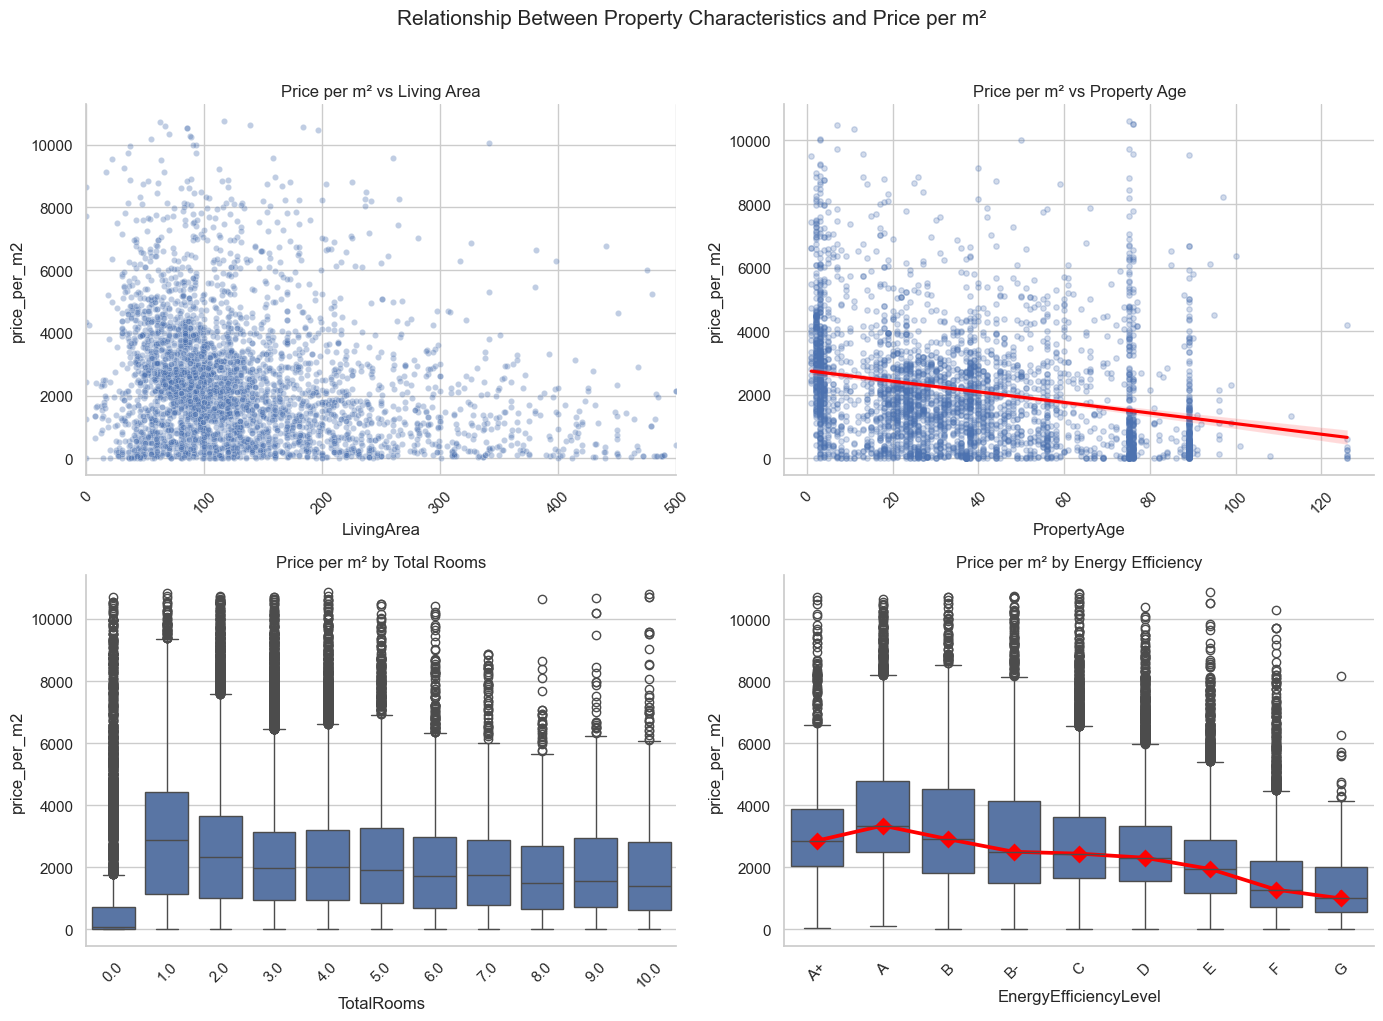

In [34]:
plot_property_characteristics_vs_price(df_clean)

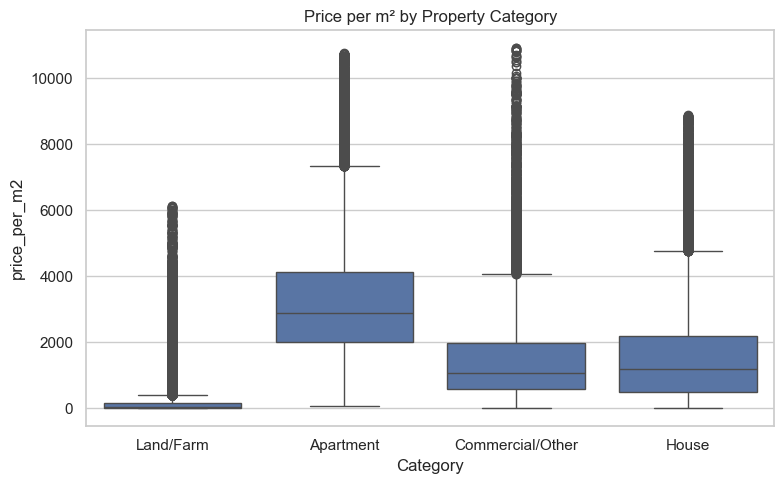

In [35]:
plot_price_by_property_category(df_clean)

**Additional relationship: age and energy efficiency**

Properties with better energy efficiency ratings tend to be newer, which is consistent with modern construction standards.

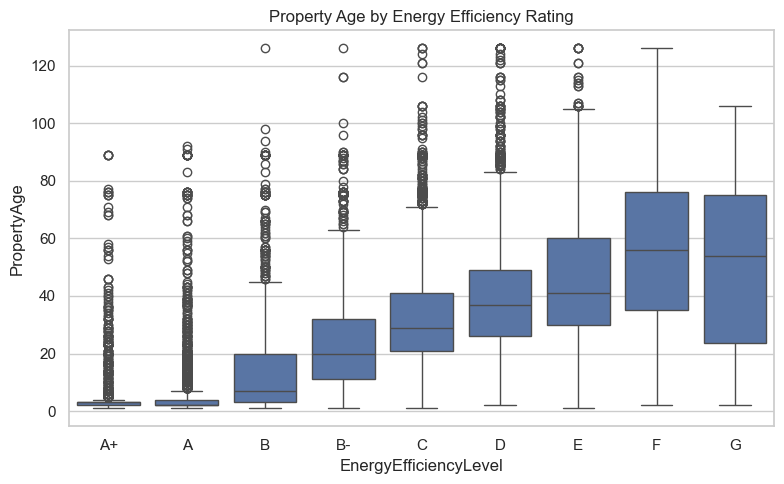

In [36]:
plot_property_age_by_energy_efficiency(df_clean)

## 3.2 Geographic Price Differences
   
Major metropolitan areas such as Lisbon and Porto show significantly higher   
price levels compared to smaller cities, reflecting stronger demand, tourism activity,    
and economic concentration.

These price leaders are typically explained by:  
**1. Urban economic centers**  
**Lisbon and Porto** are Portugal’s main economic hubs  
higher employment opportunities  
higher population density  
**2. Tourism demand**  
**Faro and Algarve** region are major tourist destinations  
many properties used for holiday homes or rentals  
**3. Coastal attractiveness**  
coastal regions generally command higher real estate prices  
**4. Limited supply**  
historic city centers have restricted space for new construction  

In [37]:
district_median = (
    df_clean.groupby("District")["price_per_m2"]
    .median()
    .sort_values(ascending=False)
)

district_count = (
    df_clean.groupby("District")["Price"]
    .count()
    .loc[district_median.index]
)

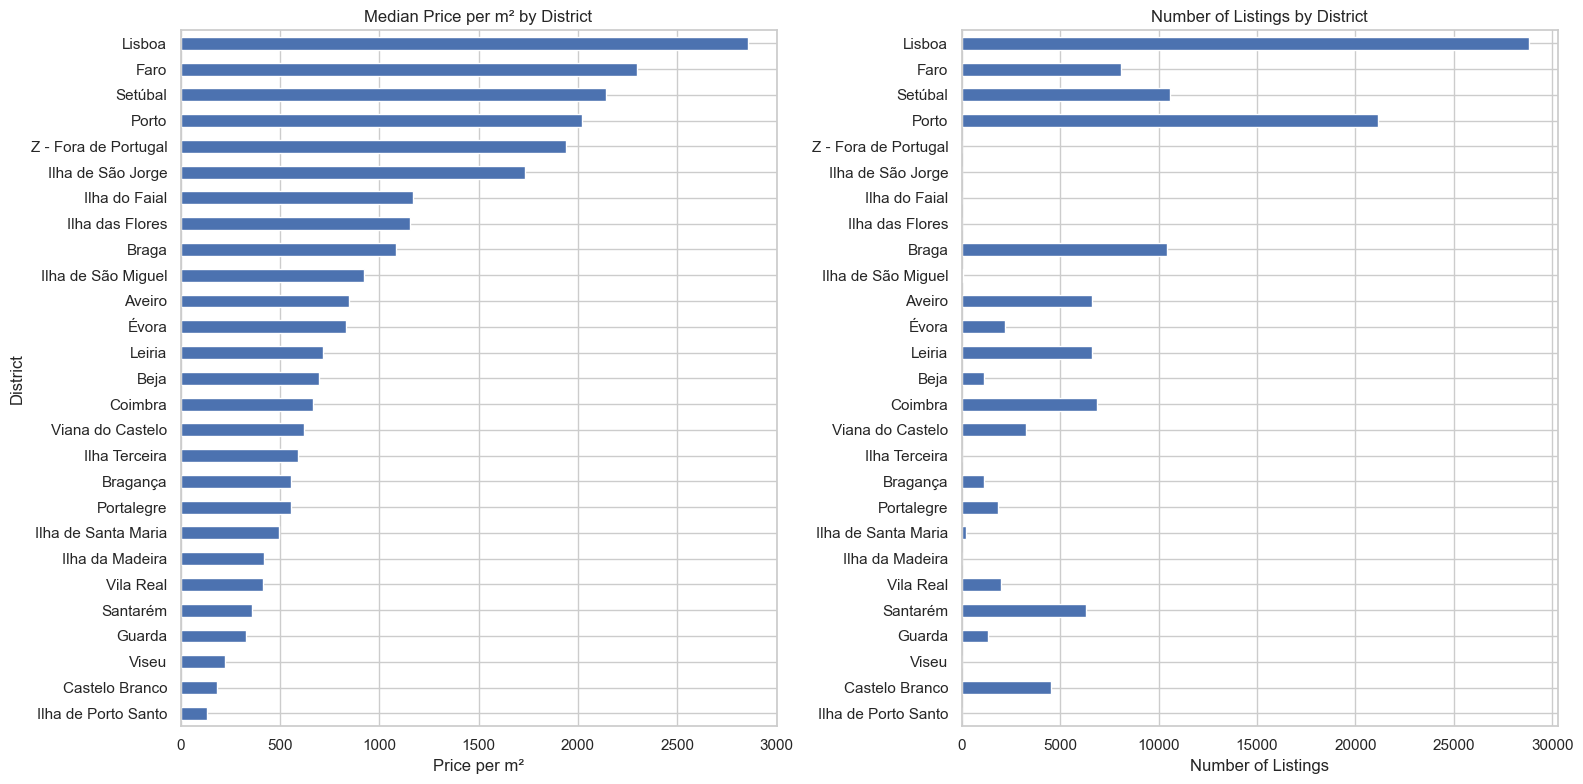

In [38]:
plot_district_price_and_listing_counts(district_median, district_count)

## 3.3 Property Characteristics  

Price per square meter varies significantly depending on property category.     
Apartments generally show the highest price per square meter due to their    
concentration in urban areas.

**1. Apartments are consistently the most expensive property type**  
Across almost all districts, apartments show the highest median price    
per square meter compared to houses, commercial properties, and land.   
- Apartments usually located in urban centers;
- Higher demand and population density.

**2. Land/Farm properties are the cheapest per m²**  
Land and farm properties exhibit the lowest price per square meter across most districts.  
- Large land sizes;  
- Rural locations;  
- Lower development density.  

**3. Coastal and urban districts such as Lisboa, Faro, Setúbal,    
and Porto tend to have higher property prices than inland regions.**    
- Economic activity;  
- Tourism;  
- Population concentration.

**4. Price dispersion differs across categories**  
Apartments and houses show wider price variability within districts,    
indicating diverse property characteristics and location effects.   
- Luxury vs basic apartments;   
- City center vs outskirts.

In [39]:
order = (
    df_clean.groupby("District")["price_per_m2"]
    .median()
    .sort_values()
    .index
)

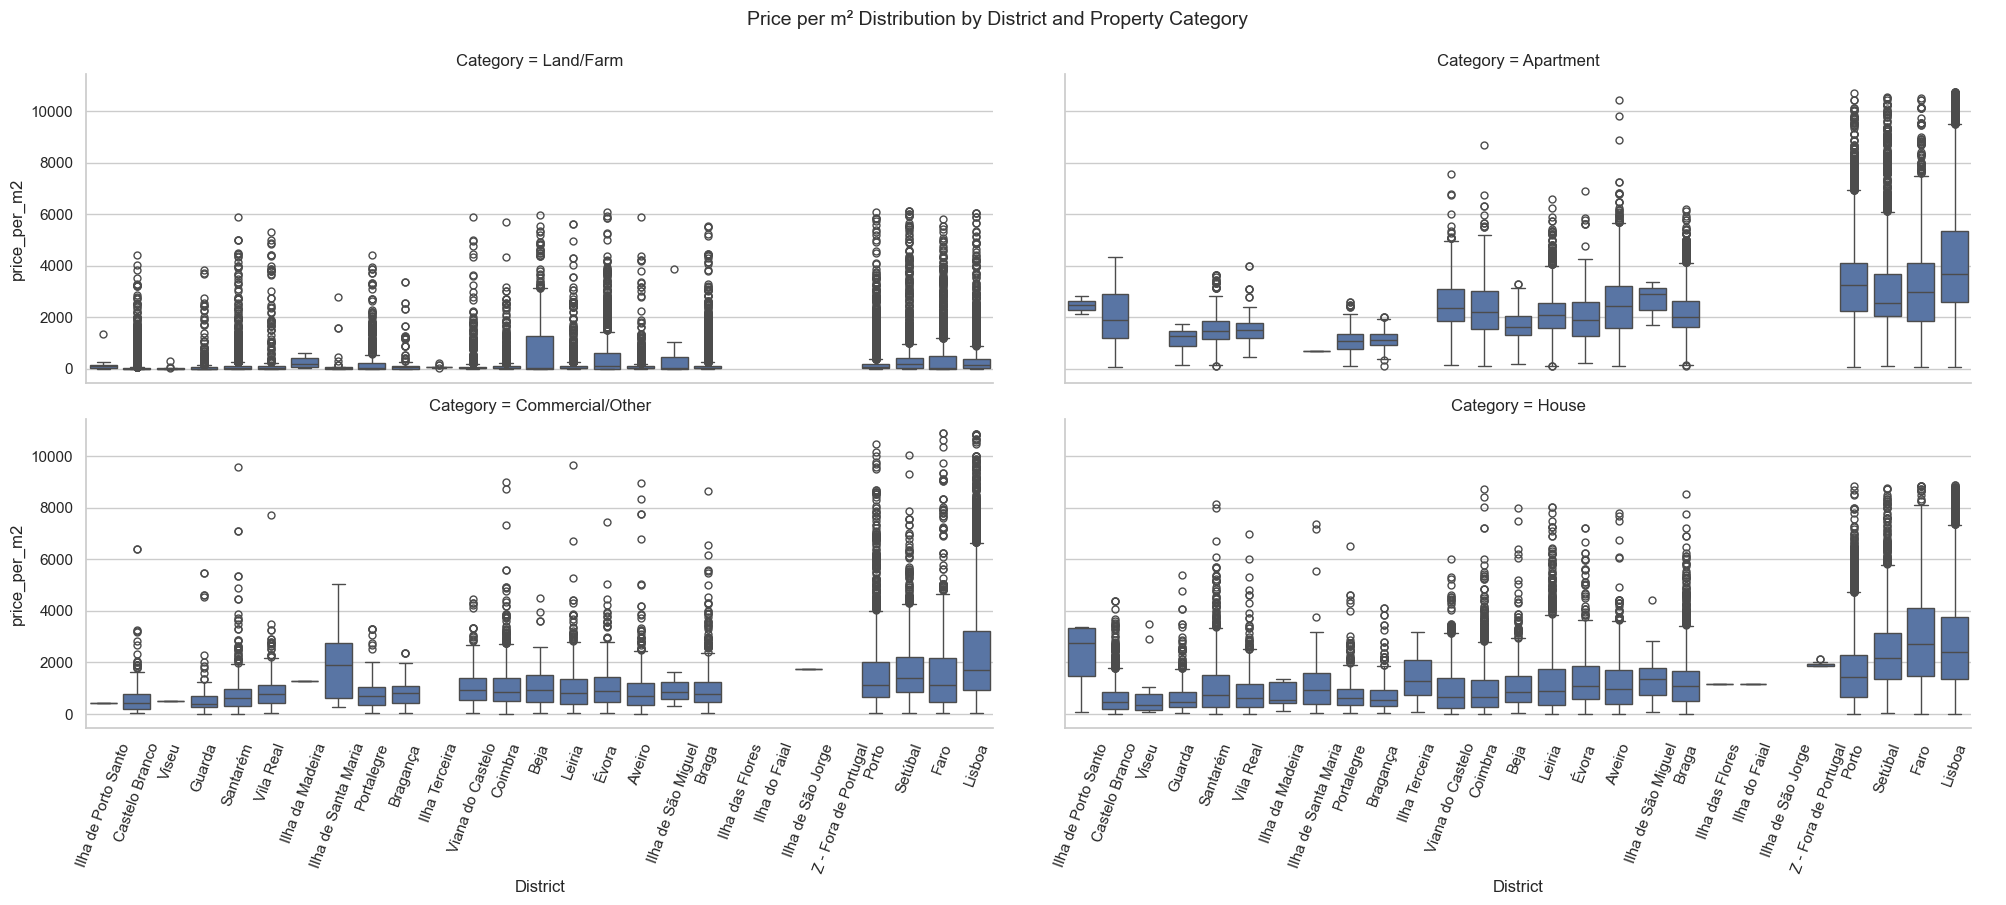

In [40]:
plot_district_category_distribution(df_clean, order)

**Top cities**

**1. Lisbon has the highest apartment prices**
Lisbon shows the highest median apartment price per square meter among    
the selected cities, confirming its position as the most expensive housing market in Portugal.   
- Capital city  
- Economic center  
- Tourism  
- International demand  

**2. Cascais and Oeiras are premium residential areas**  
Cascais and Oeiras also exhibit relatively high property prices,  
particularly for apartments and houses, reflecting their proximity   
to Lisbon and high residential attractiveness.  
These are known high-income suburbs.   

**3. Porto shows strong price levels but slightly lower than Lisbon**  
Porto demonstrates strong housing prices, although generally lower   
than Lisbon, reflecting its role as Portugal's second-largest economic center.  

**4. Land prices vary more between cities**  
Land prices show significant variability between cities, suggesting strong    
influence of local development potential and land availability.

In [134]:
top_cities = (
    df_clean.groupby("City")["price_per_m2"]
    .median()
    .sort_values(ascending=False)
    .head(7)
    .index
)

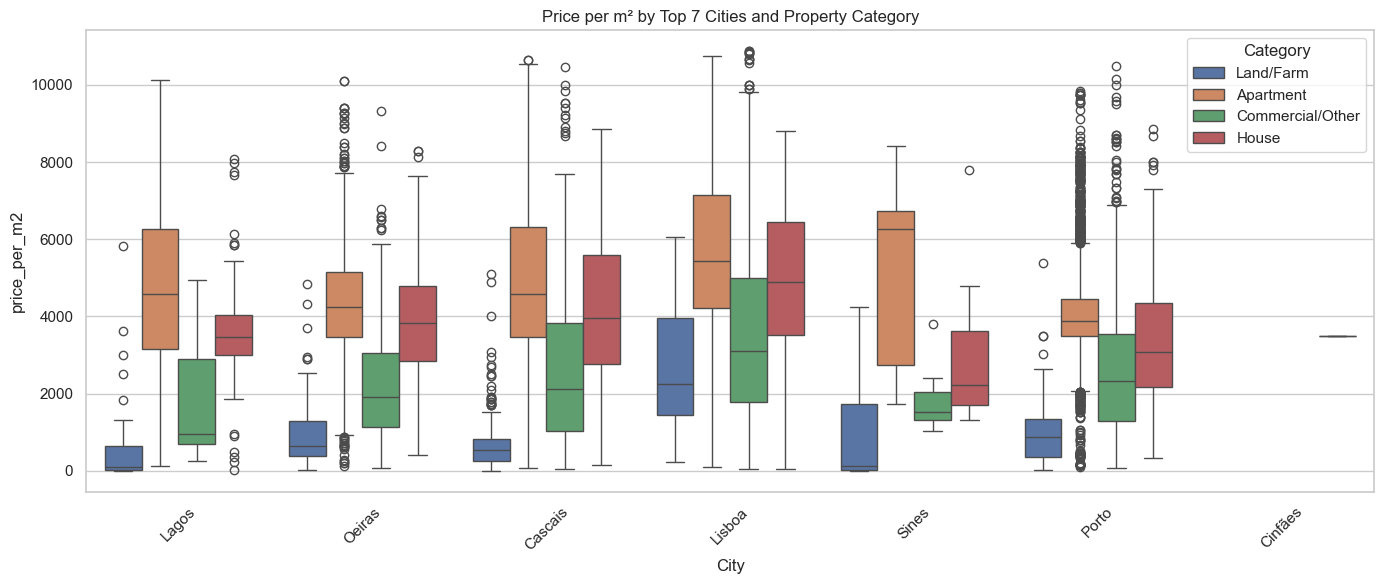

In [135]:
plot_top_cities_by_category(df_clean, top_cities)

**Map**

**Coordinates for districts**

In [43]:
district_coords = {
    "Lisboa": (38.7223, -9.1393),
    "Porto": (41.1579, -8.6291),
    "Faro": (37.0194, -7.9322),
    "Braga": (41.5454, -8.4265),
    "Coimbra": (40.2033, -8.4103),
    "Aveiro": (40.6405, -8.6538),
    "Leiria": (39.7436, -8.8070),
    "Setúbal": (38.5244, -8.8882),
    "Viseu": (40.6610, -7.9097),
    "Guarda": (40.5373, -7.2673),
    "Bragança": (41.8060, -6.7567),
    "Castelo Branco": (39.8222, -7.4909),
    "Évora": (38.5714, -7.9135),
    "Beja": (38.0151, -7.8632),
    "Portalegre": (39.2967, -7.4280),
    "Viana do Castelo": (41.6932, -8.8329),
    "Vila Real": (41.3006, -7.7441),
    "Santarém": (39.2362, -8.6859)
}

1. *Agregate data*  
2. *Filter only mainland Portugal*  
3. *Merge coordinates*  
4. *Create map*

In [44]:
category_dropdown = widgets.Dropdown(
    options=["All"] + sorted(df_clean["Category"].dropna().unique()),
    value="All",
    description="Category:"
)

widgets.interactive(
    lambda category: realestateplot.plot_map(df_clean, category, district_coords),
    category=category_dropdown
)

interactive(children=(Dropdown(description='Category:', options=('All', 'Apartment', 'Commercial/Other', 'Hous…

**Apartments**  
- Highest prices in Lisbon and coastal areas  
- Large number of listings  

**Commercial**  
- More concentrated around economic centers  

**Houses**  
- Wider distribution across the country  

**Land/Farm**  
- Lowest price per m²  
- Mostly inland and rural  

Overall, the map confirms that Portugal’s real estate market is strongly   
influenced by geographic factors, with urban and coastal districts   
consistently exhibiting higher property prices and greater listing density.  

**Correlation analysis**

The correlation matrix was computed using **Pearson** correlation, which measures linear relationships  
between numerical variables. Since `df_clean.corr(numeric_only=True)` was used, Pearson correlation  
is applied by default.

To account for potential non-linear or monotonic relationships and the presence of outliers, **Spearman**  
correlation was also computed as a non-parametric alternative.

Both correlation heatmaps show consistent patterns, indicating that the relationships between features   
and price are largely monotonic. However, Spearman correlation reveals stronger relationships, suggesting  
that some dependencies are not strictly linear.

The results show that property size-related features such as TotalArea, LivingArea, TotalRooms, and NumberOfBathrooms  
have the strongest positive relationship with price. This confirms that larger properties tend to have higher prices.

Some structural variables (e.g., TotalRooms and NumberOfBathrooms) also demonstrate moderate positive correlations,  
reinforcing their importance in price estimation.

A high correlation between TotalArea and LivingArea indicates potential multicollinearity, meaning these variables  
capture similar information about property size. Tree-based models such as Random Forest are generally robust to  
multicollinearity, so both features were retained.

In [45]:
corr = df_clean.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

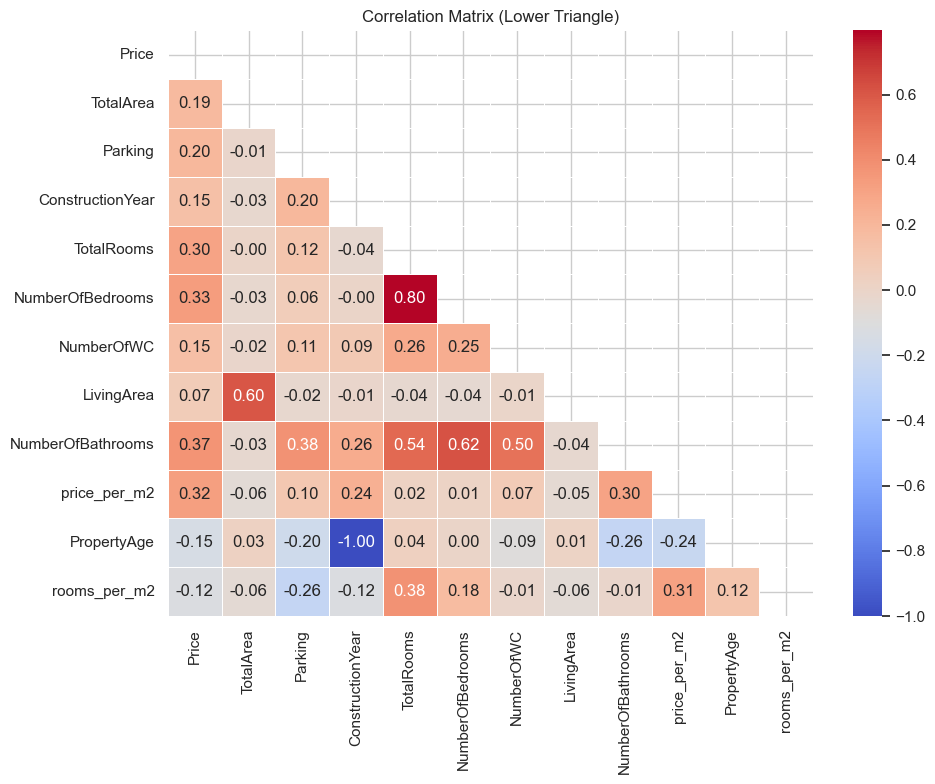

In [46]:
plot_correlation_heatmap(corr, mask)

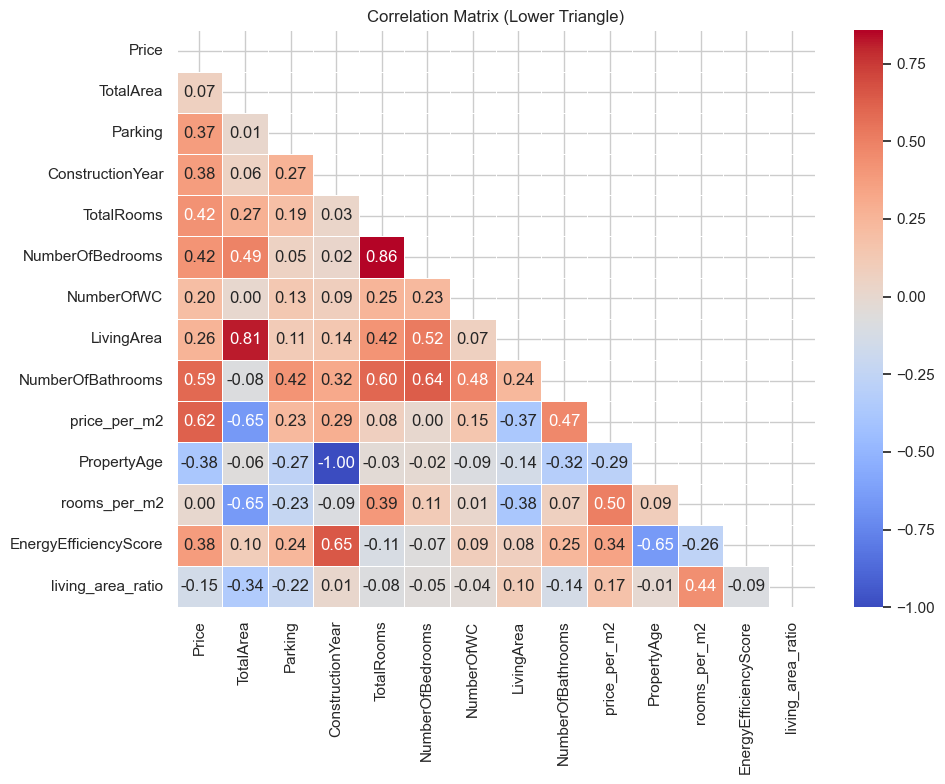

In [131]:
corr_spearman = df_clean.corr(method="spearman", numeric_only=True)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
plot_correlation_heatmap(corr_spearman, mask)

**Correlation with target**

Property size and room-related features show the strongest relationships with total property price.  
Older properties tend to have slightly lower prices compared to newer constructions.

In [47]:
corr = df_clean.corr(numeric_only=True)["Price"].sort_values()

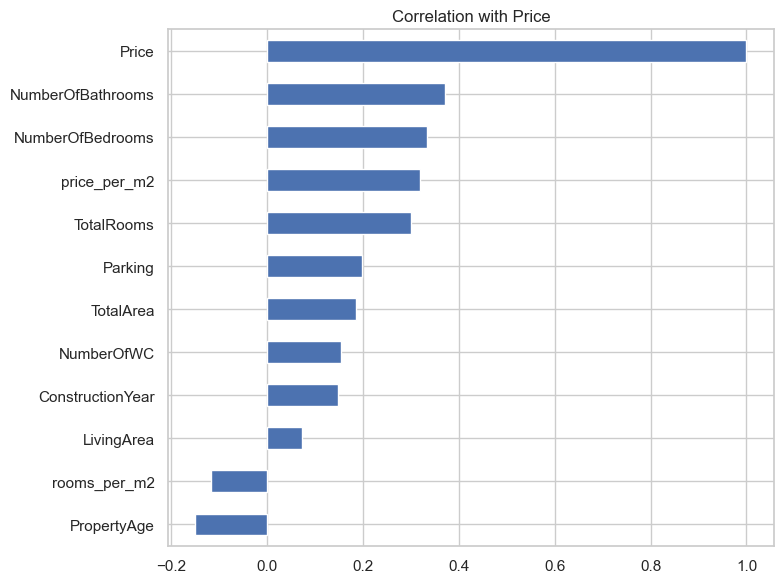

In [48]:
plot_correlation_with_price(corr)

------------------------------------------------------------------------------------

# 4. Hypothesis Testing  

Target population: residential and commercial real estate listings in   
Portugal represented by the available dataset. The statistical inference    
in this project aims to draw conclusions about pricing patterns in this    
population, while acknowledging that the data reflects listing prices   
rather than final transaction prices.  

## 4.1 Lisbon vs Porto Price Comparison  

**Question**: Do Lisbon and Porto have different average price per m²?  

**H0**: μ_Lisbon = μ_Porto  
**H1**: μ_Lisbon ≠ μ_Porto

**Test** used: **Welch t-test and Mann–Whitney U test**    
**Reason**: Price **distribution** is **not** perfectly **normal** and group variances may differ.  

**Result**:  
t = 49.88, p < 0.001

**Conclusion**:   
Since p < 0.05, we reject the null hypothesis.   
Apartment prices per m² differ significantly between Lisbon and Porto.

**Distribution check**

In [49]:
lisbon = df_clean[
    (df_clean["City"] == "Lisboa") &
    (df_clean["Category"] == "Apartment")
]["price_per_m2"].dropna()

porto = df_clean[
    (df_clean["City"] == "Porto") &
    (df_clean["Category"] == "Apartment")
]["price_per_m2"].dropna()

print("Lisbon sample:", len(lisbon))
print("Porto sample:", len(porto))

Lisbon sample: 5822
Porto sample: 4160


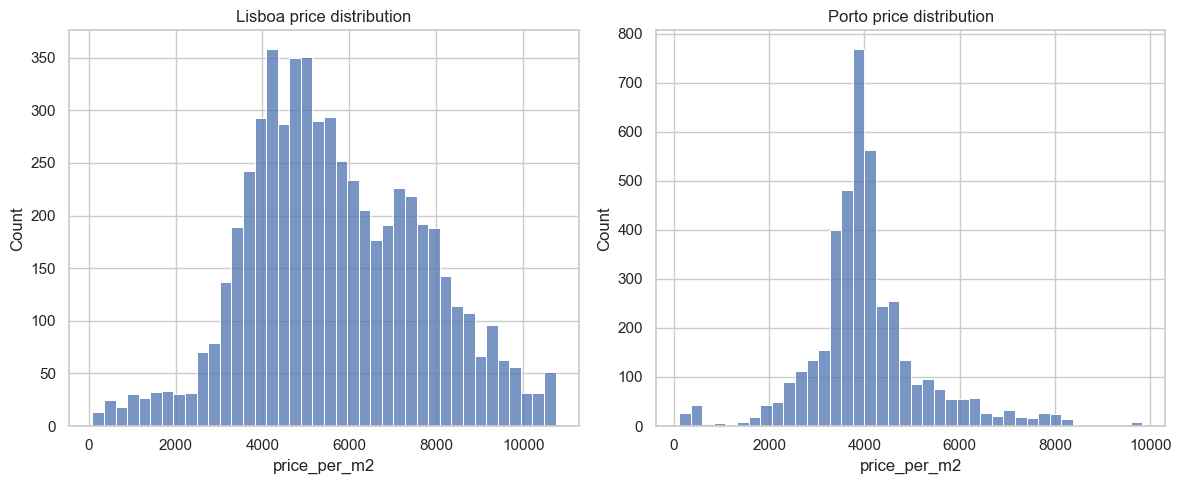

In [50]:
plot_lisbon_porto_distributions(lisbon, porto)

In [51]:
lisbon = df_clean[(df_clean["City"]=="Lisboa") & (df_clean["Category"]=="Apartment")]["price_per_m2"]
porto = df_clean[(df_clean["City"]=="Porto") & (df_clean["Category"]=="Apartment")]["price_per_m2"]

ttest_ind(lisbon, porto, equal_var=False)

TtestResult(statistic=np.float64(49.87907750433798), pvalue=np.float64(0.0), df=np.float64(9777.844325423737))

In [52]:
def cohens_d(a,b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.var(a) + np.var(b)) / 2)

cohens_d(lisbon, porto)

np.float64(0.9738916917708751)

In [53]:
mannwhitneyu(lisbon, porto, alternative="two-sided")

MannwhitneyuResult(statistic=np.float64(18532156.5), pvalue=np.float64(0.0))

A **Welch’s t-test** revealed a **statistically significant** difference in price   
per square meter between Lisbon and Porto (t = 49.88, p < 0.001).   

The **effect size was large** (Cohen’s d = 0.97), indicating a substantial    
difference between the two markets. A **Mann–Whitney U** test confirmed the    
**robustness** of this result (p < 0.001).  

Due to the large sample size, even moderate differences can become   
statistically significant; therefore effect size was also evaluated.

## 4.2 Hypothesis 2 - Property Age Effect

**Question**: Do newer properties have higher price per m² than older ones?

**H0**: μ_new = μ_old  
**H1**: μ_new ≠ μ_old

**Test** used: **Mann–Whitney U** test

**Result**:  
p < 0.001

Conclusion:  
**Reject H0**. Newer properties tend to have significantly higher price per m².

In [54]:
new = df_clean[df_clean["PropertyAge"] <= 10]["price_per_m2"].dropna()
old = df_clean[df_clean["PropertyAge"] > 30]["price_per_m2"].dropna()

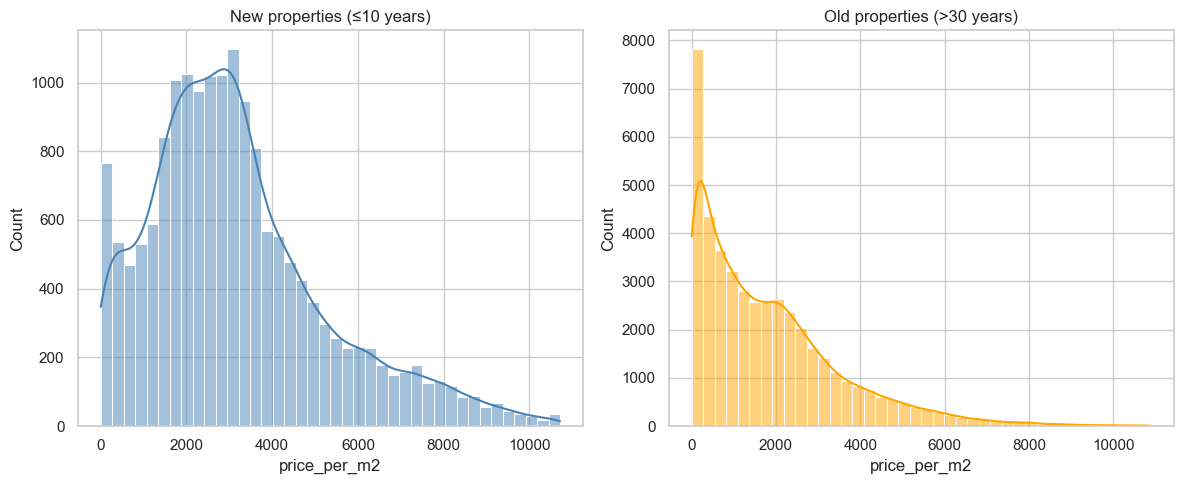

In [55]:
plot_new_old_distributions(new, old)

New properties tend to have higher price per m² than older ones.

In [56]:
mannwhitneyu(new, old, alternative="greater")

MannwhitneyuResult(statistic=np.float64(530288197.5), pvalue=np.float64(0.0))

To investigate whether property age influences price per square meter,    
properties were divided into two groups: newer properties (≤10 years)   
and older properties (>30 years). The distributions show that newer properties   
tend to have higher price levels. A **Mann–Whitney U** test confirmed  
a **statistically significant difference** between the two groups (p < 0.001),   
indicating that newer properties generally command higher prices per square meter  
compared to older properties.

## 4.3 Hypothesis 3 - Energy Efficiency Impact

**Question**:Average price per m² differs between energy efficiency groups.  

**H0**: μ_high = μ_low   
**H1**: μ_high ≠ μ_low  

**Test**: **Mann–Whitney U** (supported by Kruskal–Wallis)  
α = 0.05  

**Result**:  
p < 0.001 → reject H0  

Properties with **higher energy** efficiency ratings tend to have **higher price per m²**.

In [57]:
energy_df = df_clean[["EnergyEfficiencyLevel", "price_per_m2"]].dropna()

In [58]:
high = energy_df[
    energy_df["EnergyEfficiencyLevel"].isin(["A+","A","B"])
]["price_per_m2"]

low = energy_df[
    energy_df["EnergyEfficiencyLevel"].isin(["D","E","F","G"])
]["price_per_m2"]

In [59]:
shapiro(high.sample(min(len(high),5000)))
shapiro(low.sample(min(len(low),5000)))

ShapiroResult(statistic=np.float64(0.8981923414790032), pvalue=np.float64(1.6380987629302574e-49))

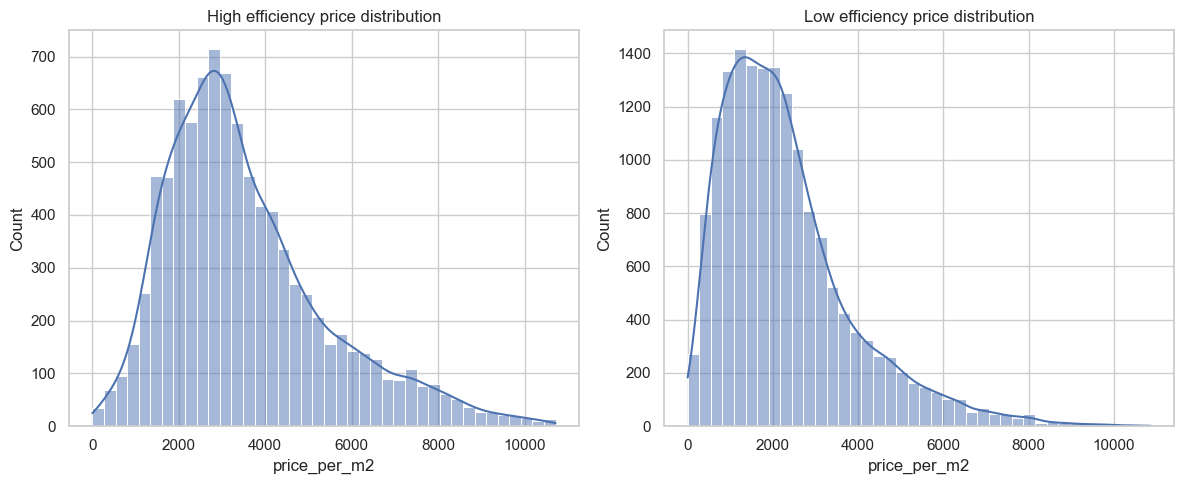

In [60]:
plot_energy_group_distributions(high, low)

In [61]:
mannwhitneyu(high, low)

MannwhitneyuResult(statistic=np.float64(106226269.0), pvalue=np.float64(0.0))

In [62]:
groups = [
    energy_df[energy_df["EnergyEfficiencyLevel"] == g]["price_per_m2"]
    for g in energy_df["EnergyEfficiencyLevel"].unique()
]

kruskal(*groups)

KruskalResult(statistic=np.float64(4765.772302179895), pvalue=np.float64(0.0))

To evaluate whether energy efficiency affects property prices, statistical   
tests were conducted on price per square meter across energy efficiency groups.  

The **Shapiro–Wilk** test indicated that the price **distribution** deviates  
from normality (p < 0.001), therefore non-parametric tests were applied.      
The **Mann–Whitney** U test showed a **significant difference** between   
high-efficiency and low-efficiency properties (p < 0.001). Additionally,    
the **Kruskal–Wallis** test confirmed that price **distributions differ significantly**    
across energy efficiency categories (H = 4765.77, p < 0.001).   
These results suggest that energy efficiency ratings are associated with differences   
in property prices.

Higher energy efficiency may increase property value due to reduced energy costs,   
modern construction standards, and increasing regulatory emphasis on sustainable   
housing within the European Union.


**All hypothesis** tests were conducted at a significance level of α = 0.05.  
A **p-value below 0.05** was treated as sufficient evidence to **reject the null hypothesis**.  

<table align="left">
<tr>
<th>Analysis</th>
<th>Question</th>
<th>Tests Used</th>
<th>Statistic</th>
<th>p-value</th>
<th>Conclusion</th>
</tr>

<tr>
<td><b>H1: Lisbon vs Porto (Apartments)</b></td>
<td>Do Lisbon and Porto have different average price per m²?</td>
<td>Welch t-test, Mann–Whitney U, Cohen’s d</td>
<td>t = 49.88, U = 18,532,156.5, d = 0.97</td>
<td>&lt; 0.001</td>
<td>Strong evidence of price difference between Lisbon and Porto. Large effect size.</td>
</tr>

<tr>
<td><b>H2: Property Age Effect</b></td>
<td>Do newer properties have higher price per m² than older ones?</td>
<td>Mann–Whitney U</td>
<td>U = 530,288,197.5</td>
<td>&lt; 0.001</td>
<td>Newer properties tend to have significantly higher price per m².</td>
</tr>

<tr>
<td><b>H3: Energy Efficiency Effect</b></td>
<td>Does energy efficiency affect price per m²?</td>
<td>Shapiro–Wilk, Mann–Whitney U, Kruskal–Wallis</td>
<td>W = 0.903, U = 106,226,269, H = 4765.77</td>
<td>&lt; 0.001</td>
<td>Energy efficiency rating significantly affects price per m².</td>
</tr>


</table>

<br clear="all">


## 4.4 Confidence Interval Estimation

In [63]:
def confidence_interval(data, confidence=0.95):
    data = data.dropna()
    mean = np.mean(data)
    sem = stats.sem(data)  
    margin = sem * stats.t.ppf((1 + confidence) / 2., len(data)-1)
    
    return mean - margin, mean + margin

ci_results = {}

for category in df_clean["Category"].unique():
    data = df_clean[df_clean["Category"] == category]["price_per_m2"]
    ci_results[category] = confidence_interval(data)

#ci_results

In [64]:
ci_table = []

for category in df_clean["Category"].unique():
    data = df_clean[df_clean["Category"] == category]["price_per_m2"].dropna()
    
    mean = data.mean()
    lower, upper = confidence_interval(data)
    
    ci_table.append([category, mean, lower, upper])

pd.DataFrame(ci_table, columns=["Category","Mean price/m²","CI lower","CI upper"])

,Category,Mean price/m²,CI lower,CI upper
0,Land/Farm,259.172136,251.259611,267.084660
1,Apartment,3279.008720,3262.014021,3296.003419
2,Commercial/Other,1582.215490,1555.799310,1608.631671
3,House,1583.870615,1568.543584,1599.197646


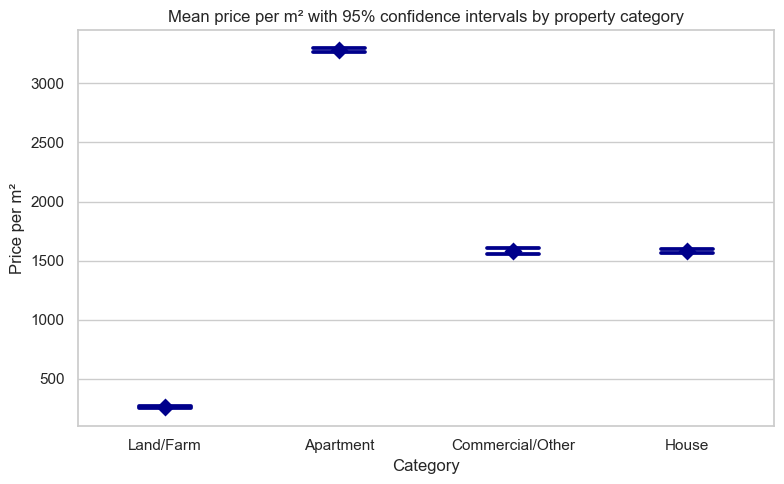

In [65]:
plot_category_confidence_intervals(df_clean)

The **confidence interval** analysis shows clear differences in average price    
per square meter across property categories. Apartments exhibit the highest   
average price per m² (≈3279 €/m²), with a relatively narrow 95% confidence interval,   
indicating a precise estimate of the population mean. Houses and commercial properties   
display substantially lower average prices (≈1580 €/m²), while land and farm properties   
show the lowest values (≈259 €/m²).

The limited overlap between confidence intervals suggests that property  
**category plays a significant role in determining price** per square meter.

---------------------------------

# 5. Feature Engineering and Preprocessing
## 5.1 Target Definition and Leakage Prevention

- Additional features
- Numerical and categorical features were separated  
- Missing values were imputed  
- Categorical features were encoded using One-Hot Encoding  
- All preprocessing steps were implemented within a Scikit-Learn Pipeline to prevent data leakage.

In [66]:
df_clean["living_area_ratio"] = (
    df_clean["LivingArea"] / df_clean["TotalArea"].replace(0, np.nan)
)

df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

In [68]:
drop_cols = [
    "Price",
    "price_per_m2",
   # "log_price",
    "ConstructionYear",
    "EnergyEfficiencyLevel",
    "Category"
]

In [69]:
X = df_clean.drop(columns=drop_cols)
y = df_clean["Price"]

In [70]:
df_clean["EnergyEfficiencyScore"] = pd.to_numeric(
    df_clean["EnergyEfficiencyScore"],
    errors="coerce"
)
X["EnergyEfficiencyScore"] = pd.to_numeric(X["EnergyEfficiencyScore"], errors="coerce")

print("Target shape:", y.shape)
print("Feature matrix shape:", X.shape)
print(X.columns.tolist())

Target shape: (123407,)
Feature matrix shape: (123407, 15)
['District', 'City', 'Town', 'Type', 'TotalArea', 'Parking', 'TotalRooms', 'NumberOfBedrooms', 'NumberOfWC', 'LivingArea', 'NumberOfBathrooms', 'PropertyAge', 'rooms_per_m2', 'EnergyEfficiencyScore', 'living_area_ratio']


In [71]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123407 entries, 0 to 123406
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   District               123407 non-null  object 
 1   City                   123407 non-null  object 
 2   Town                   123405 non-null  object 
 3   Type                   123407 non-null  object 
 4   TotalArea              123407 non-null  float64
 5   Parking                123248 non-null  float64
 6   TotalRooms             70357 non-null   float64
 7   NumberOfBedrooms       45492 non-null   float64
 8   NumberOfWC             49388 non-null   float64
 9   LivingArea             101502 non-null  float64
 10  NumberOfBathrooms      118395 non-null  float64
 11  PropertyAge            84908 non-null   float64
 12  rooms_per_m2           70357 non-null   float64
 13  EnergyEfficiencyScore  35141 non-null   float64
 14  living_area_ratio      101502 non-nu

In [72]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object","category"]).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['TotalArea', 'Parking', 'TotalRooms', 'NumberOfBedrooms', 'NumberOfWC', 'LivingArea', 'NumberOfBathrooms', 'PropertyAge', 'rooms_per_m2', 'EnergyEfficiencyScore', 'living_area_ratio']
Categorical: ['District', 'City', 'Town', 'Type']


**Build preprocessing pipelines**

In [73]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

**Categorical pipeline**

In [74]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

**Combine pipelines with ColumnTransformer**

In [75]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

**First split (train vs temp)**

In [76]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

**Second split (validation vs test)**

In [77]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (86384, 15)
Validation size: (18511, 15)
Test size: (18512, 15)


The dataset was split into three parts:  

• Training set (70%) – used to train the models  
• Validation set (15%) – used for model comparison and hyperparameter tuning  
• Test set (15%) – used only for final evaluation  

Using a validation set prevents information leakage and ensures that model selection is not biased by the test data.

Stratification was not applied because this is a regression problem, where the target variable (price) is continuous.  
Unlike classification tasks, direct stratification is not straightforward. While it is possible to stratify using  
binned target values, this was not implemented, as the dataset is sufficiently large and representative.

----------------------------------------------------

# 6. Machine Learning Models

Models evaluated:  
- Dummy Regressor (baseline)  
- Linear Regression  
- Decision Tree  
- Random Forest  
- Gradient Boosting  
- Voting Regressor (ensemble)  

Evaluation metrics:  
- RMSE  
- MAE  
- R²  

**Define evaluation metrics**

In [78]:
def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

**DummyRegressor baseline**

In [79]:
dummy_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_model.fit(X_train, y_train)

y_val_pred_dummy = dummy_model.predict(X_val)

dummy_rmse, dummy_mae, dummy_r2 = evaluate_regression(y_val, y_val_pred_dummy)

print("Dummy Regressor")
print("RMSE:", round(dummy_rmse, 2))
print("MAE:", round(dummy_mae, 2))
print("R²:", round(dummy_r2, 4))

Dummy Regressor
RMSE: 550570.17
MAE: 268050.33
R²: -0.0002


**Linear Regression baseline**

In [80]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_val_pred_linear = linear_model.predict(X_val)

linear_rmse, linear_mae, linear_r2 = evaluate_regression(y_val, y_val_pred_linear)

print("Linear Regression")
print("RMSE:", round(linear_rmse, 2))
print("MAE:", round(linear_mae, 2))
print("R²:", round(linear_r2, 4))

Linear Regression
RMSE: 439577.1
MAE: 179804.84
R²: 0.3624


In [81]:
baseline_results = pd.DataFrame({
    "Model": ["Dummy Regressor", "Linear Regression"],
    "RMSE": [dummy_rmse, linear_rmse],
    "MAE": [dummy_mae, linear_mae],
    "R²": [dummy_r2, linear_r2]
})

baseline_results.round(2)

,Model,RMSE,MAE,R²
0,Dummy Regressor,550570.17,268050.33,-0.00
1,Linear Regression,439577.10,179804.84,0.36


**Dummy Regressor** model simply predicts the average property price for every observation.  
- The model explains no variance in the data  
- It performs the same as predicting the mean price for every listing  
 
**Linear Regression** model significantly improves performance compared to the naive baseline,  
indicating that the selected features provide meaningful predictive power.  
However, the relatively large prediction errors and moderate R² value suggest that linear models  
are insufficient to capture the complex, non-linear relationships present in the housing data.  
- The model explains 36% of the variance in price  
- This confirms that the selected features contain predictive information  
- Prediction errors are still large (~€180k average error)  
- The model likely cannot capture non-linear relationships  
   - non-linear effects  
   - skewed distributions  
   - strong interactions between features

Housing prices usually depend on non-linear relationships, such as:  
- location effects  
- diminishing returns for property size  
- interactions between features  
- neighborhood effects  
Linear regression cannot model these well.  

Because real estate prices often exhibit non-linear relationships between variables,    
tree-based models such as Decision Trees, Random Forests, and Gradient Boosting are   
expected to provide improved predictive performance.

**Non-linear models**  
**Decision Tree Regressor**

In [82]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)

y_val_pred_dt = dt_model.predict(X_val)

dt_rmse, dt_mae, dt_r2 = evaluate_regression(y_val, y_val_pred_dt)

**Random Forest Regressor**

In [83]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict(X_val)

rf_rmse, rf_mae, rf_r2 = evaluate_regression(y_val, y_val_pred_rf)

**Gradient Boosting Regressor**

In [84]:
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

y_val_pred_gb = gb_model.predict(X_val)

gb_rmse, gb_mae, gb_r2 = evaluate_regression(y_val, y_val_pred_gb)

## 6.1 Model Comparison

Tree-based ensemble models significantly outperformed linear models, suggesting that    
property price relationships are highly non-linear.
Random Forest achieved the best validation performance.

In [85]:
ml_results = pd.DataFrame({
    "Model": [
        "Dummy Regressor",
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "RMSE": [
        dummy_rmse,
        linear_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],
    "MAE": [
        dummy_mae,
        linear_mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],
    "R²": [
        dummy_r2,
        linear_r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]
})

ml_results.round(2)

,Model,RMSE,MAE,R²
0,Dummy Regressor,550570.17,268050.33,-0.00
1,Linear Regression,439577.10,179804.84,0.36
2,Decision Tree,370241.51,103426.60,0.55
3,Random Forest,311455.75,91486.53,0.68
4,Gradient Boosting,369951.77,145246.81,0.55


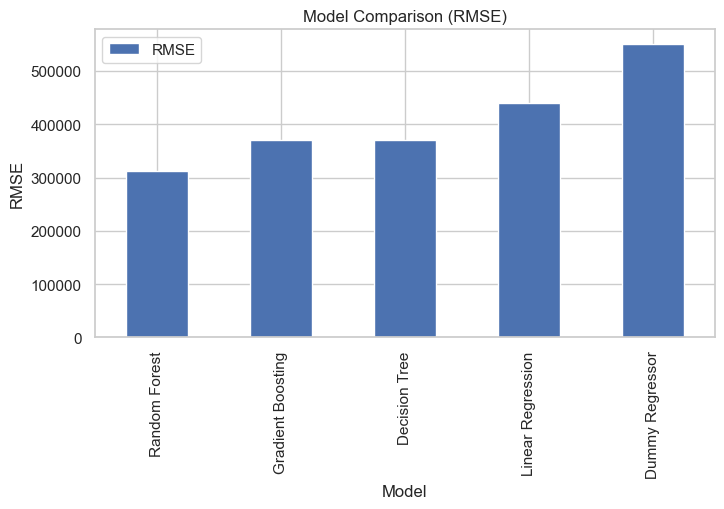

In [86]:
plot_model_comparison_rmse(ml_results)

**Non-linear Models**

Model comparison shows a clear improvement when moving from simple to more complex models.  

The **Dummy Regressor** serves as a baseline and simply predicts the average price.    
As expected, it performs poorly with an RMSE of **550,570** and an R² close to 0,   
indicating **no predictive power**.

**Linear Regression** improves the results (RMSE 439,577, R² 0.36), showing    
that some linear **relationships** between **features and price** exist.

However, **tree-based** models significantly **outperform** linear models,   
indicating that the relationship between property features and price is non-linear.

The **Decision Tree** model reduces RMSE to **370,241** and increases R² to **0.55**,    
showing that non-linear splits capture more structure in the data.

The **Random Forest** model achieves the **best performance** among the tested models    
with an RMSE of **311,455** and an R² of **0.68**. This improvement is expected    
because Random Forest averages predictions from many trees, reducing variance   
and overfitting. And R² = 0.68 means that the model explains 68% of the variance  
in property prices.

**Gradient Boosting** does not outperform Random Forest in this configuration,    
producing results similar to a single decision tree. This suggests that further    
hyperparameter tuning may be required for boosting models to reach their full potential.   

Overall, ensemble tree-based models appear to be the most suitable approach for    
predicting property prices in this dataset.

------------------------------------------

# 7. Hyperparameter Tuning

In [88]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="r2",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
print("Best RF CV score:", rf_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best RF params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 30}
Best RF CV score: 0.5961374992042295


In [89]:
best_rf = rf_search.best_estimator_
y_val_pred_rf_tuned = best_rf.predict(X_val)

rf_tuned_rmse, rf_tuned_mae, rf_tuned_r2 = evaluate_regression(y_val, y_val_pred_rf_tuned)
print(rf_tuned_rmse, rf_tuned_mae, rf_tuned_r2)

325126.5615051482 109841.17287326463 0.6512097452201666


**Tune Gradient Boosting**

In [90]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.8, 1.0],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_dist,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)
print("Best GB params:", gb_search.best_params_)
print("Best GB CV RMSE:", -gb_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best GB params: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1}
Best GB CV RMSE: 354960.3487528891


In [91]:
best_gb = gb_search.best_estimator_
y_val_pred_gb_tuned = best_gb.predict(X_val)

gb_tuned_rmse, gb_tuned_mae, gb_tuned_r2 = evaluate_regression(y_val, y_val_pred_gb_tuned)

print("Tuned GB Validation RMSE:", gb_tuned_rmse)
print("Tuned GB Validation MAE:", gb_tuned_mae)
print("Tuned GB Validation R²:", gb_tuned_r2)

Tuned GB Validation RMSE: 337075.54275949544
Tuned GB Validation MAE: 125499.50619056822
Tuned GB Validation R²: 0.6251013080284441


In [92]:
tuned_results = pd.DataFrame({
    "Model": [
        "Random Forest (tuned)",
        "Gradient Boosting (tuned)"
    ],
    "RMSE": [
        rf_tuned_rmse,
        gb_tuned_rmse
    ],
    "MAE": [
        rf_tuned_mae,
        gb_tuned_mae
    ],
    "R²": [
        rf_tuned_r2,
        gb_tuned_r2
    ]
})

tuned_results.round(2)

all_results = pd.concat([ml_results, tuned_results], ignore_index=True)
all_results.round(2).sort_values("RMSE")

,Model,RMSE,MAE,R²
3,Random Forest,311455.75,91486.53,0.68
5,Random Forest (tuned),325126.56,109841.17,0.65
6,Gradient Boosting (tuned),337075.54,125499.51,0.63
4,Gradient Boosting,369951.77,145246.81,0.55
2,Decision Tree,370241.51,103426.60,0.55
1,Linear Regression,439577.10,179804.84,0.36
0,Dummy Regressor,550570.17,268050.33,-0.00


Hyperparameter tuning was performed using **RandomizedSearchCV** with   
**3-fold cross-validation**to ensure that model performance was evaluated   
across multiple training splits and to reduce the risk of overfitting,    
evaluating 15 parameter combinations for each model (45 fits in total).    
The optimization metric was **RMSE**, which measures the average prediction   
error in the same units as the target variable (price).

The best Random Forest configuration included **100 trees, a maximum depth of 30**,     
and a **minimum split size of 5 samples**. The best Gradient Boosting model used    
**300 estimators, a learning rate of 0.1**, and a **maximum depth of 5**.

Although hyperparameter tuning improved the **cross-validation RMSE** during the    
search phase, the tuned models did **not outperform the original Random Forest model   
on the validation set**. The baseline Random Forest achieved the best performance with:   
- **RMSE**: 311,455   
- **MAE**: 91,486  
- **R²**: 0.68   

The tuned Random Forest slightly underperformed compared to the baseline configuration.    
This can happen when the default parameters already provide a strong balance between    
bias and variance for the given dataset.

Overall, the results indicate that **Random Forest remains the strongest individual model**,    
suggesting that ensemble bagging methods are well suited for capturing the    
complex relationships in real estate price data.

**VotingRegressor**

In [93]:
voting_model = VotingRegressor([
    ("lr", Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])),
    ("rf", Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ])),
    ("gb", Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.1,
            random_state=42
        ))
    ]))
])

**Train the ensemble**

In [94]:
voting_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting eac

**Evaluate on validation set**

In [95]:
y_val_pred_voting = voting_model.predict(X_val)

voting_rmse, voting_mae, voting_r2 = evaluate_regression(y_val, y_val_pred_voting)

print("Voting Regressor")
print("RMSE:", round(voting_rmse, 2))
print("MAE:", round(voting_mae, 2))
print("R²:", round(voting_r2, 4))

Voting Regressor
RMSE: 342916.56
MAE: 124135.56
R²: 0.612


In [96]:
ensemble_results = pd.DataFrame({
    "Model": ["Voting Regressor"],
    "RMSE": [voting_rmse],
    "MAE": [voting_mae],
    "R²": [voting_r2]
})

all_results = pd.concat([all_results, ensemble_results], ignore_index=True)
all_results.round(2).sort_values("RMSE")

,Model,RMSE,MAE,R²
3,Random Forest,311455.75,91486.53,0.68
5,Random Forest (tuned),325126.56,109841.17,0.65
6,Gradient Boosting (tuned),337075.54,125499.51,0.63
7,Voting Regressor,342916.56,124135.56,0.61
4,Gradient Boosting,369951.77,145246.81,0.55
2,Decision Tree,370241.51,103426.60,0.55
1,Linear Regression,439577.10,179804.84,0.36
0,Dummy Regressor,550570.17,268050.33,-0.00


To further explore model performance, a **Voting Regressor ensemble** was     
created by combining Linear Regression, Random Forest, and Gradient Boosting models.   
The ensemble aggregates predictions from multiple models, aiming to reduce prediction    
variance and capture different patterns in the data.

However, the ensemble model did **not outperform the best individual model**.   
The Voting Regressor achieved:  
- **RMSE**: 342,916  
- **MAE**: 124,135  
- **R²**: 0.61  

While the ensemble improved over simpler models such as Linear Regression and  
Decision Trees, it performed worse than the standalone Random Forest model.   
This suggests that the Random Forest already captures most of the predictive    
structure in the dataset, and combining it with weaker models may slightly    
dilute its predictive strength.

Based on these results, **Random Forest** remains the most **effective model**    
for predicting property prices in this dataset.

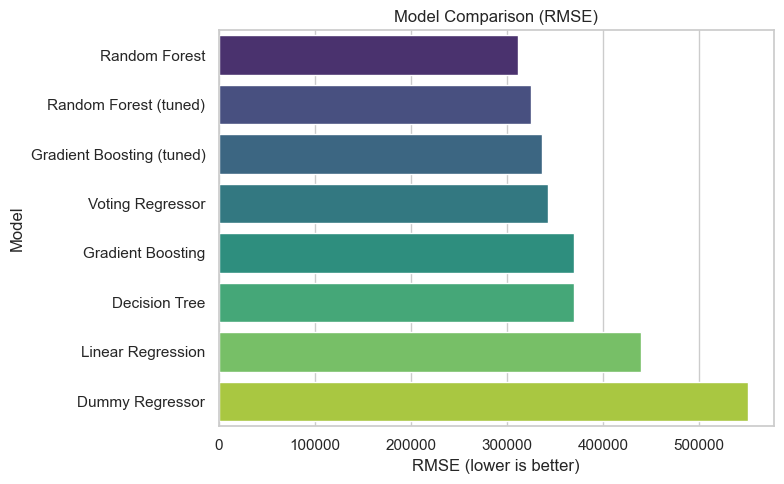

In [97]:
plot_model_rmse_comparison(all_results)

Based on the validation results, the Random Forest model achieved the best   
predictive performance among all tested models. It produced the lowest RMSE   
and MAE values and the highest R² score, indicating the strongest ability to    
explain variance in property prices. Therefore, Random Forest was selected as   
the final model for evaluation on the unseen test dataset.

-------------------------------------------

# 8. Final Model Evaluation

In [98]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

In [99]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=30,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features=None,
        random_state=42,
        n_jobs=-1
    ))
])

final_model.fit(X_train_full, y_train_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [100]:
y_test_pred = final_model.predict(X_test)

test_rmse, test_mae, test_r2 = evaluate_regression(y_test, y_test_pred)

print("Final Model Performance (Test Set)")
print("RMSE:", round(test_rmse,2))
print("MAE:", round(test_mae,2))
print("R²:", round(test_r2,4))

Final Model Performance (Test Set)
RMSE: 323150.1
MAE: 110744.55
R²: 0.6446


**Final Model Performance (Test Set)**

Random Forest was selected as the final model because it achieved the lowest validation 
RMSE and the highest R² among all evaluated and tuned models. 

Other approaches, including the Voting Regressor and tuned Gradient Boosting,
were tested but did not surpass its performance. Additionally, Random Forest provided stable 
results and handled non-linear relationships effectively, making it a reliable choice for this problem.

The final Random Forest model was evaluated on the previously unseen test dataset    
to assess its generalization performance. The model achieved the following results:   
- **RMSE**: 323,150  
- **MAE**: 110,744  
- **R²**: 0.65  

These results indicate that the model explains approximately   
**65% of the variance in property prices**, suggesting that the selected features    
capture a substantial portion of the price variability. 

The **Mean Absolute Error (MAE)** of around **110,000** means that,     
on average, the predicted property price differs from the actual price      
by approximately €110,000. Considering that property prices in the dataset    
range from a few thousand euros to several million euros, this level of    
prediction error is expected for real estate data, which typically contains     
high variability and location-specific factors.

The **RMSE** value is larger than MAE because it penalizes larger prediction    
errors more strongly, indicating that some high-priced properties are harder     
to predict accurately. This pattern is common in housing datasets, where    
luxury properties often have unique characteristics that are difficult to     
capture using structured features alone.

Overall, the Random Forest model demonstrates solid predictive performance   
and confirms that **ensemble tree-based methods are effective for modeling complex,    
non-linear relationships in real estate price data**.

## 8.1 Prediction Diagnostics  

The increasing spread of residuals for higher predicted prices suggests  
heteroscedasticity, meaning that prediction errors grow with property value.  
This behavior is common in housing datasets where high-end properties exhibit  
greater variability in pricing.  

### 8.1.1 Actual vs Predicted plot

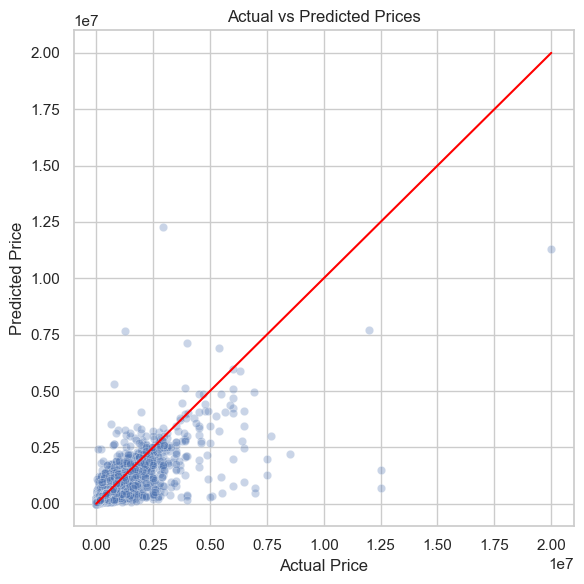

In [101]:
plot_actual_vs_predicted(y_test, y_test_pred)

The scatter plot shows that predicted prices generally follow the  
trend of the actual property prices. Most predictions lie close to   
the diagonal reference line, indicating that the model captures the  
overall pricing structure reasonably well.  

However, higher-value properties show greater dispersion,  
suggesting that the model has more difficulty accurately predicting  
extreme price values.

### 8.1.2 Residuals vs Predicted plot

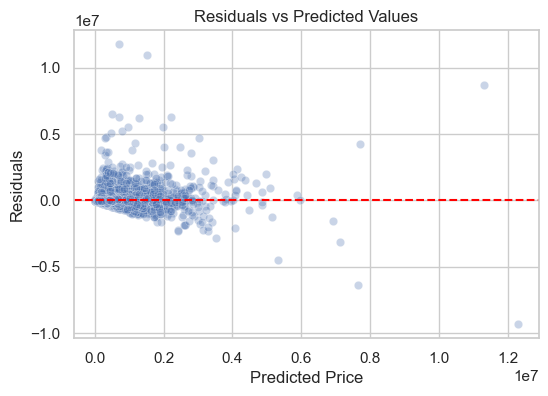

In [102]:
y_test_pred = final_model.predict(X_test)
residuals = y_test - y_test_pred

plot_residuals_vs_predicted(y_test_pred, residuals)

Residual analysis shows that prediction errors are centered around zero,  
indicating that the model does not systematically overestimate or underestimate   
property prices.  

However, the spread of residuals increases for higher predicted prices,  
suggesting mild heteroscedasticity, which is common in real estate data where  
high-value properties tend to exhibit greater price variability.  

## 8.2 Feature Importance

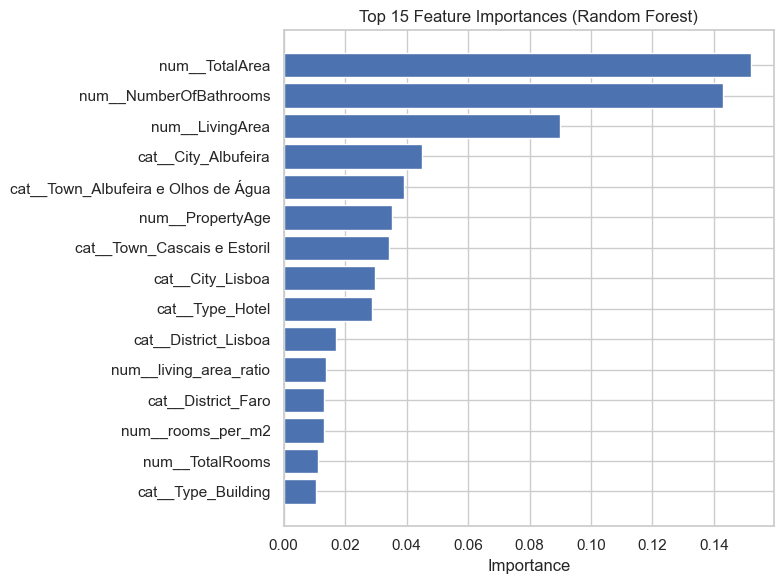

In [104]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plot_feature_importance(feat_imp, top_n=15)

Feature importance analysis from the Random Forest model reveals that property  
size-related features have the strongest influence on price prediction.  

The most important predictors are:  
• TotalArea  
• NumberOfBathrooms  
• LivingArea  
 
This suggests that the physical size of a property is the primary driver of  
price in the dataset.    

Location-related variables such as City_Albufeira, Town_Cascais e Estoril,  
and City_Lisboa also appear among the most important features, confirming that  
location plays a significant role in determining property value.  

PropertyAge has moderate influence, while variables such as TotalRooms and  
rooms_per_m2 have smaller contributions compared to overall property size  
and location.

-----------------------------------------------------------------

# 9. Model Deployment


In [109]:
joblib.dump(final_model, "C:/Users/netad/project/deployment/house_price_model.joblib")

['C:/Users/netad/project/deployment/house_price_model.joblib']

In [111]:
loaded_model = joblib.load("C:/Users/netad/project/deployment/house_price_model.joblib")

sample = X_test.iloc[[0]].copy()
pred = loaded_model.predict(sample)
print(pred)

[590785.75183482]


In [112]:
print(X.columns.tolist())

['District', 'City', 'Town', 'Type', 'TotalArea', 'Parking', 'TotalRooms', 'NumberOfBedrooms', 'NumberOfWC', 'LivingArea', 'NumberOfBathrooms', 'PropertyAge', 'rooms_per_m2', 'EnergyEfficiencyScore', 'living_area_ratio']


The final selected model was the **Random Forest** pipeline, which included both the preprocessing steps   
and the trained regression model. On the unseen test set, the final model achieved **RMSE = 323,150**,  
**MAE = 110,745**, and **R² = 0.6446**, indicating solid predictive performance for a real estate pricing problem.  

To make the model usable outside the notebook, it was deployed as a **REST API**. The trained pipeline was first   
serialized with **joblib**, which allowed the full preprocessing-and-model workflow to be saved and reused without retraining.  

The deployment architecture was:

**Notebook → serialized model (house_price_model.joblib) → FastAPI application → Docker container  
→ Google Artifact Registry → Google Cloud Run**

A **FastAPI** service was created to expose the model through an **HTTP endpoint**. The API accepts property  
characteristics in JSON format and returns a predicted price. Using FastAPI provided a lightweight and   
production-friendly way to serve the model with built-in request validation and interactive API documentation through Swagger UI.  

To ensure consistent execution across environments, the API was packaged in a Docker container.   
Containerization is useful because it guarantees that the same Python version, libraries, and model files  
are used both locally and in the cloud. This avoids dependency issues and makes the service reproducible and portable.   

The Docker image was then uploaded to **Google Artifact Registry** and deployed to **Google Cloud Run**.   
Cloud Run was chosen because it provides a simple managed deployment option for containerized applications   
and makes the service accessible through a public HTTPS URL. As a result, the trained model can now be called   
through HTTP requests from external applications.

The deployed API exposes a POST /predict endpoint. A sample request is shown below:

Response:

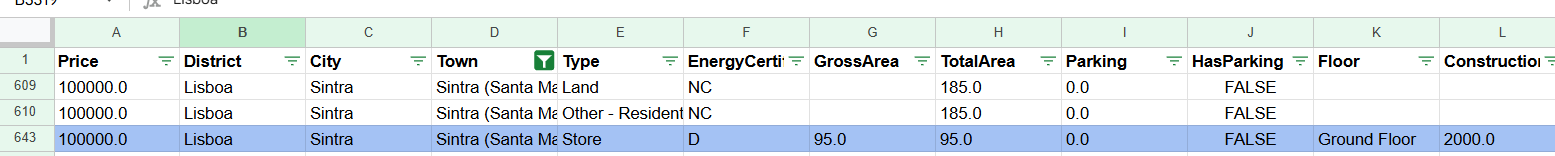
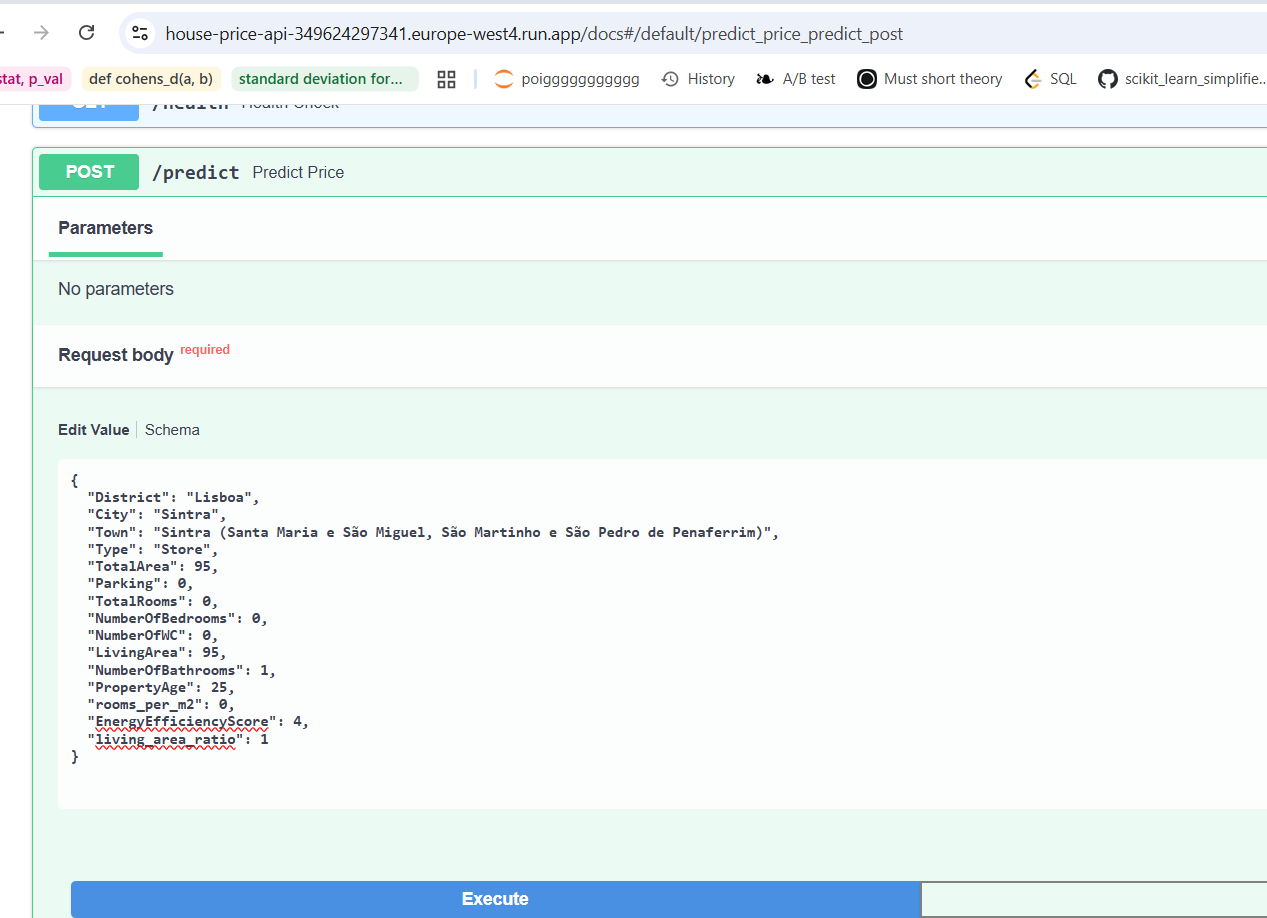
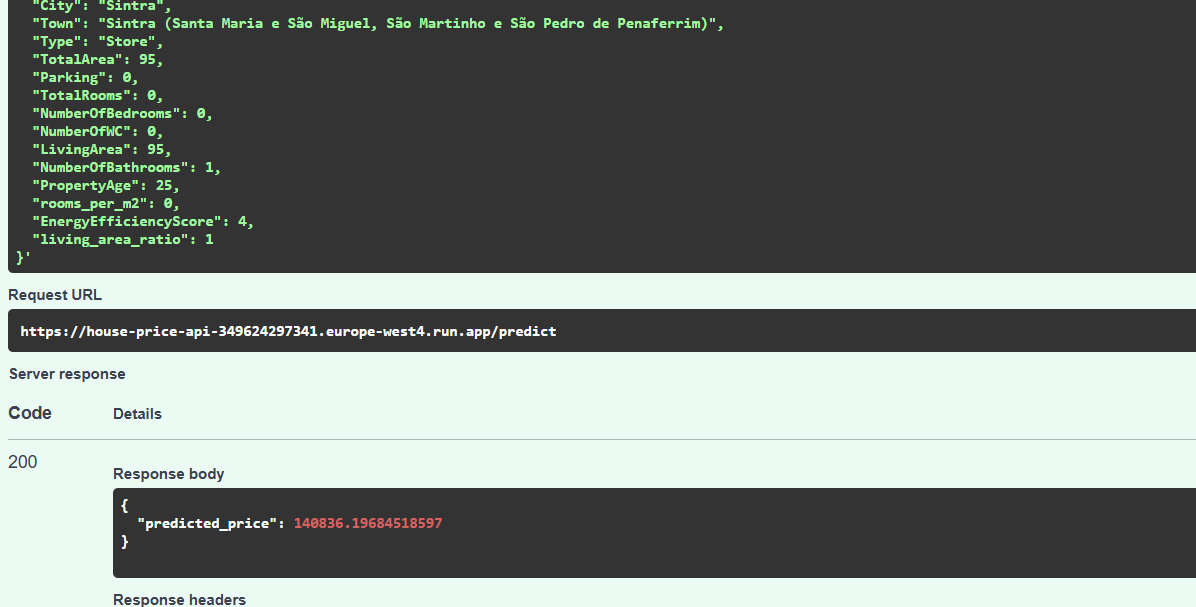

In [138]:
HTML(r"""
<video width="600" controls>
  <source src="C:/Users/netad/OneDrive/Desktop/Videoradius Screen Recorder/portugal_estate.mp4" type="video/mp4">
</video>

<script>
var video = document.querySelector("video");
video.currentTime = 5;
</script>
""")

The deployment was successfully verified both locally and in the cloud. Locally, the API was tested    
through FastAPI’s /docs interface and returned valid predictions. After containerization and deployment    
to Cloud Run, the same endpoint produced successful predictions through the public URL, confirming that    
the deployed service works correctly as an HTTP-accessible machine learning application.

**Deployment files**  

The deployment folder contained the following main files:  
- *app.py* — FastAPI application with the prediction endpoint  
- *house_price_model.joblib* — serialized trained pipeline  
- *requirements.txt* — Python dependencies  
- *Dockerfile* — container configuration  

**Deployment result**

The final result is a deployed machine learning service that predicts Portuguese real estate   
listing prices from user-provided property features. This satisfies the project requirement to  
containerize the best-performing model and deploy it to Google Cloud Platform so that predictions are  
callable via HTTP request.

------------------------------------------------------------------

# 10. Limitations

• Property listings may not reflect final transaction prices.  
• Dataset lacks precise geolocation coordinates.  
• Property condition and renovation status are not available.  
• Market trends and macroeconomic indicators are not included.  

# 11. Project Conclusions  

This project demonstrated that property characteristics such as location,    
size, number of rooms, and energy efficiency are significant predictors of    
real estate prices.
Tree-based ensemble models were particularly effective in capturing complex   
interactions between features.
The Random Forest model achieved the best predictive performance and was    
successfully deployed as a cloud-based prediction service.

----------------------------------------------------------------

# 12. Suggestions for Improvement

Several improvements could further enhance this analysis:  
- Incorporating additional location features such as distance to city center or public transportation.  
- Including economic indicators such as mortgage rates or income levels.  
- Using geospatial models to capture regional price clustering.  
- Applying advanced ensemble methods such as XGBoost or LightGBM.
- Stratified splitting based on binned price ranges to ensure more balanced distribution across train and test sets. 
- Increasing interpretability using SHAP or feature importance analysis.